In [1]:
import sys
import importlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

sys.path.append("/Users/arthurbenard/Project 1B/src")

In [2]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import catboost
from catboost import CatBoostClassifier

my_model = joblib.load('final_model.joblib')

In [3]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, learning_curve, GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [5]:
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint, scrub, compress_fingerprints_pca, calculate_descriptors, extract_solvent_physics, calculate_mlwt
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df, add_matrix_id_to_df, run_descriptor_competition, run_hyperparameter_competition, unknown_column_machine_test, strict_unknown_column_machine_test
from analysis.analysis import run_ablation_study, plot_comparison, run_data_fraction, plot_learning_curve, run_ablation_xgboost, learning_curve_trainsize_kselectors, run_matrix_ablation, accuracy_per_matrix, rt_bin_analysis, mw_bin_analysis, solvent_bin_analysis

In [6]:
def plot_shap_mw_rt_correlation(loaded_model, df, phys_feature_list):
    print("Calculating SHAP values to map the MW/RT interaction\n")
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "MolWt",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index="RT",  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('AI Learned Interaction: Molecular Weight vs. Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

In [30]:
# Creating the new dataframe, the first steps can be kept
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
raw_df['SMILES'] = raw_df['solute_smiles'].astype(str).str.strip()

# Deleting rows with signals = 0
raw_df = raw_df[raw_df['RT'] != 0].copy()

raw_df = raw_df[~raw_df['SMILES'].str.contains(' ', na=False)].copy()

solvent_cols = ['MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3']

id_cols = ['Column', 'Method', 'RT', 'Signal', 
           'Matrix ID Name', 'solute_smiles']

df_desc = raw_df.melt(
    id_vars=id_cols,
    value_vars=solvent_cols,
    var_name='Solvent_Name',
    value_name='Soluble'
)

df_desc = df_desc.rename(columns={'solute_smiles': 'SMILES'})

In [31]:
# Removes 'matrix ID ' in the original column names (was a problem)
df_desc['Matrix ID Name'] = df_desc['Matrix ID Name'].str.replace('matrix ID ', '', regex=False).str.strip()

# The first step is to rename the columns in the given file
matrix_vectors_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/matrixIDs.xlsx')
matrix_vectors_df = matrix_vectors_df.rename(columns={'MatrixID': 'Matrix ID Name'})

# Looks at all the column headers in the file. If the header starts with the letter 'M', adds it to my list.  That way, if new components are 
# given the code adapts easily.
m_cols = [col for col in matrix_vectors_df.columns if col.startswith('M') and col != 'Matrix ID Name']

# Creating a dictionnary, .iterrows() function tells Python to read file line by line and creates key/value pair by grabbing numbers inside m_cols 
# then converting them to decimals then wrapping them in a single array.
matrix_vector_dict = {
    row['Matrix ID Name']: row[m_cols].values.astype(float)
    for _, row in matrix_vectors_df.iterrows()
}

# .map() instantly looks at 'Matrix ID Name' for all rows and attributes the specific array
df_desc['Matrix_Packed_Array'] = df_desc['Matrix ID Name'].map(matrix_vector_dict)


In [32]:
print("1/3 Mapping Solvent Physics...")
unique_solvents = pd.DataFrame({'Solvent_Name': df_desc['Solvent_Name'].unique()})
unique_solvents[['Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']] = unique_solvents['Solvent_Name'].apply(extract_solvent_physics).apply(pd.Series)
df_desc = df_desc.merge(unique_solvents, on='Solvent_Name', how='left')

1/3 Mapping Solvent Physics...


In [33]:
print("2/3 Mapping SMILES Descriptors...")
unique_smiles_other =pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles_other[['MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles_other['SMILES'].apply(calculate_mlwt).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles_other, on='SMILES', how='left')

2/3 Mapping SMILES Descriptors...


In [ ]:
print("3/3 Generating Structural Fingerprints...")
fp_dict = {smi: smiles_to_fingerprint(smi) for smi in df_desc['SMILES'].unique()}
df_desc['Sample Fingerprint'] = df_desc['SMILES'].map(fp_dict)

print(f"\n DATASET GENERATED SUCCESSFULLY")

In [34]:
matrix_vectors_df = pd.DataFrame(
    df_desc['Matrix_Packed_Array'].tolist(),
    # We dynamically name them Matrix_Vector_1, Matrix_Vector_2, etc.
    columns=[f"Matrix_Vector_{i+1}" for i in range(len(df_desc['Matrix_Packed_Array'].iloc[0]))]
)

df_desc = pd.concat([df_desc.reset_index(drop=True), matrix_vectors_df.reset_index(drop=True)], axis=1)

Calculating SHAP values to map the MW/RT interaction

Generating SHAP Dependence Plot


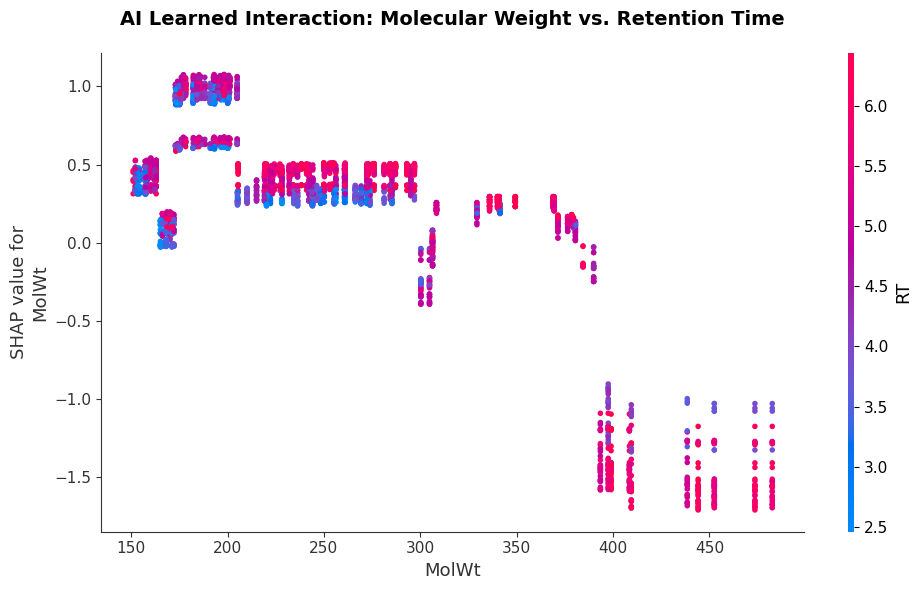

In [16]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_mw_rt_correlation(my_model, df_desc, my_features)

In [11]:
def plot_shap_rt_correlation(loaded_model, df, phys_feature_list):
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "RT",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index=None,  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('SHAP values for Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

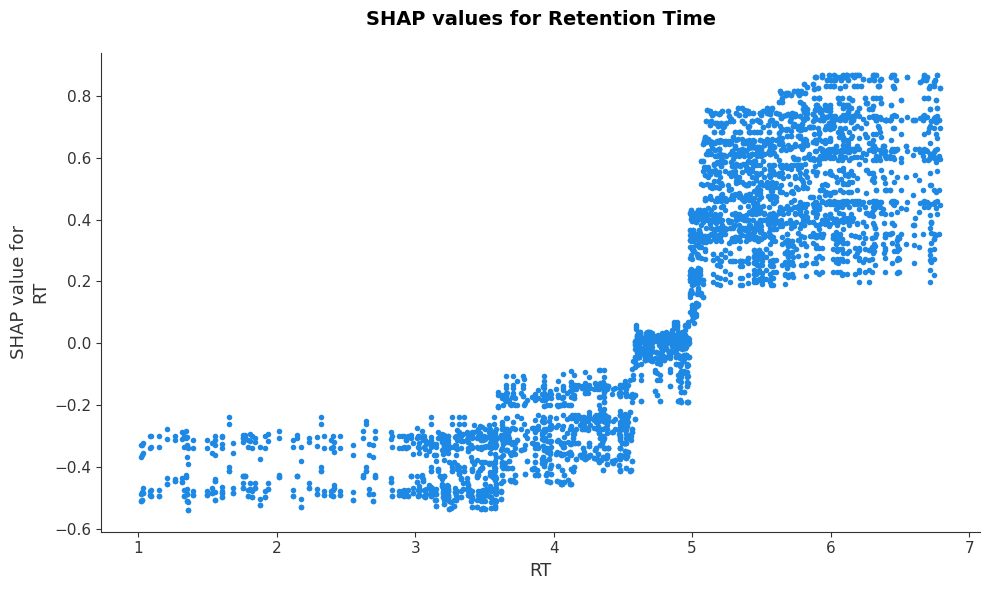

In [ ]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_rt_correlation(my_model, df_desc, my_features)

In [195]:
def plot_custom_shap_categorical(loaded_model, df, phys_feature_list, base_feature, color_col):
    
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    feature_names = ['RT'] + phys_feature_list + [f"Matrix_{i+1}" for i in range(10)]
    
    # --- 2. CALCULATE SHAP VALUES ---
    explainer = shap.TreeExplainer(loaded_model)
    shap_values = explainer.shap_values(X_final)
    
    # --- 3. ISOLATE THE SPECIFIC MATH WE NEED ---
    # Find exactly which column number belongs to our base_feature (e.g., 'MolWt')
    feature_idx = feature_names.index(base_feature)
    
    # Extract only the SHAP values and raw data for that specific feature
    specific_shap_values = shap_values[:, feature_idx]
    specific_feature_data = X_final[:, feature_idx]
    
    # --- 4. THE TRICK: STITCH IT BACK TO THE TEXT DATA ---
    
    plot_df = pd.DataFrame({
        'Raw_Value': specific_feature_data,
        'SHAP_Value': specific_shap_values,
        'Color_Label': df[color_col].values  # Pulling the text directly from the original dataframe!
    })
    
    # --- 5. BUILD THE BEAUTIFUL PLOT ---
    plt.figure(figsize=(11, 6))
    sns.set_theme(style="whitegrid")
    
    # We use seaborn because it handles categorical colors effortlessly
    sns.set_theme(style="whitegrid", context="talk")
    
    fig, ax = plt.subplots(figsize=(12, 6.5))

    sns.scatterplot(
        data=plot_df,
        x='Raw_Value',
        y='SHAP_Value',
        hue='Color_Label',
        palette='Set2', # A distinct color palette perfect for different machine/solvent names
        alpha=0.5,
        s=100,
        edgecolor='white',
        linewidth=1.2,
        ax=ax
    )
    
    ax.axhline(0, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.4, zorder=0)
    
    # Typography & Spacing
    # Dynamically inject the feature name into the title for better context
    ax.set_title(f'Model E Decision Matrix: Impact of {base_feature}', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel(f'{base_feature} (Raw Value)', fontsize=14, labelpad=12)
    ax.set_ylabel('SHAP Value\n(Impact on Solubility)', fontsize=14, labelpad=12)
    
    legend = ax.legend(
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        title=color_col.replace('_', ' ').title(), # Automatically clean up underscores in the title
        frameon=False,       # Strips off the ugly black box around the legend
        fontsize=12
    )
    # Make just the legend title bold
    legend.get_title().set_fontweight('bold')
    
    # The Despine (Removes the top/right/bottom/left box lines to open up the graph)
    sns.despine(ax=ax, left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

In [198]:
def evaluate_by_solvent(df, phys_feature_list,scale_weight, solvent_col='Solvent_Name'):
    
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    
    # Get the row indices for the training and testing sets
    train_idx, test_idx = next(splitter.split(df, groups=df['SMILES']))
    
    # Create the actual DataFrames
    df_train = df.iloc[train_idx].copy()
    df_test = df.iloc[test_idx].copy()
    
    
    # REBUILD FEATURE MATRICES FOR BOTH SETS ---
    def build_matrix(data):
        X_rt = data[['RT']].values 
        X_phys = data[phys_feature_list].values 
        X_mat = np.vstack(data['Matrix_Packed_Array'].values)
        return np.hstack((X_rt, X_phys, X_mat)), data['Soluble'].values

    X_train, y_train = build_matrix(df_train)
    X_test, y_test = build_matrix(df_test)

    # TRAIN ON THE STUDY MATERIAL ---
    
    honest_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, subsample=0.8,
    colsample_bytree=0.5,colsample_bynode=0.9, gamma=.8, min_child_weight=10, reg_lambda=5, reg_alpha=1,  scale_pos_weight=scale_weight, 
    random_state=72, n_jobs=-1)
    honest_model.fit(X_train, y_train)

    # GRADE ON THE UNSEEN TEST MATERIAL ---
    
    y_pred = honest_model.predict(X_test)
    
    results_df = pd.DataFrame({
        'Solvent': df_test[solvent_col],
        'Actual': y_test,
        'Predicted': y_pred
    })
    
    solvent_grades = []
    for solvent, group in results_df.groupby('Solvent'):
        acc = accuracy_score(group['Actual'], group['Predicted'])
        prec = precision_score(group['Actual'], group['Predicted'], zero_division=0) 
        
        solvent_grades.append({
            'Solvent': solvent,
            'Unseen_Molecules_Tested': len(group),
            'True_Accuracy': round(acc * 100, 2),
            'True_Precision': round(prec * 100, 2)
        })
        
    report_card = pd.DataFrame(solvent_grades).sort_values(by='True_Accuracy', ascending=True).reset_index(drop=True)
    
    display(report_card)
    return honest_model, report_card

In [53]:
# The target
y = df_desc['Soluble'].values

# Extracting global arrays, stacking them into clean 2D grids
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_rt = df_desc[['RT']].values 

# Splitting, ensures ALL models see the exact same train/test rows
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]

# Calculates a penalty weight
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

groups_train = df_desc.iloc[train_idx]['SMILES']

cols_E = [ 'MolWt','Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_E = np.hstack((X_rt, df_desc[cols_E].values))
X_train_E_best = np.hstack((X_cont_E[train_idx], X_mat[train_idx]))
X_test_E_best = np.hstack((X_cont_E[test_idx], X_mat[test_idx]))

In [54]:
vector_cols = [f'Matrix_Vector_{i}' for i in range(1, 11)]
xgb_cols = ['RT'] + cols_E + vector_cols

# Convert to DataFrame before training so XGBoost stores feature names
X_train_df = pd.DataFrame(X_train_E_best, columns=xgb_cols)
X_test_df  = pd.DataFrame(X_test_E_best,  columns=xgb_cols)

val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=99)
sub_train_idx, val_idx = next(val_splitter.split(
    X_train_df, y_train, groups=df_desc.iloc[train_idx]['SMILES'].values
))

X_val_df = X_train_df.iloc[val_idx]
y_val    = y_train[val_idx]
val_absolute_idx = train_idx[val_idx]  # maps back to df_desc indices

X_sub_train_df = X_train_df.iloc[sub_train_idx]
y_sub_train    = y_train[sub_train_idx]
sub_train_absolute_idx = train_idx[sub_train_idx] # maps back to df_desc indices

model_E = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, subsample=0.8,
    colsample_bytree=0.5,colsample_bynode=0.9, gamma=.8, min_child_weight=10, reg_lambda=5, reg_alpha=1,  scale_pos_weight=scale_weight, 
    random_state=72, n_jobs=-1)
model_E.fit(X_train_df, y_train)

y_pred_E = model_E.predict(X_test_df)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_E):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_E, zero_division=0):.4f}\n")

Accuracy:  0.7197
Precision: 0.8219



In [39]:
joblib.dump(model_E, 'final_model.joblib')
print("Export complete!")

Export complete!


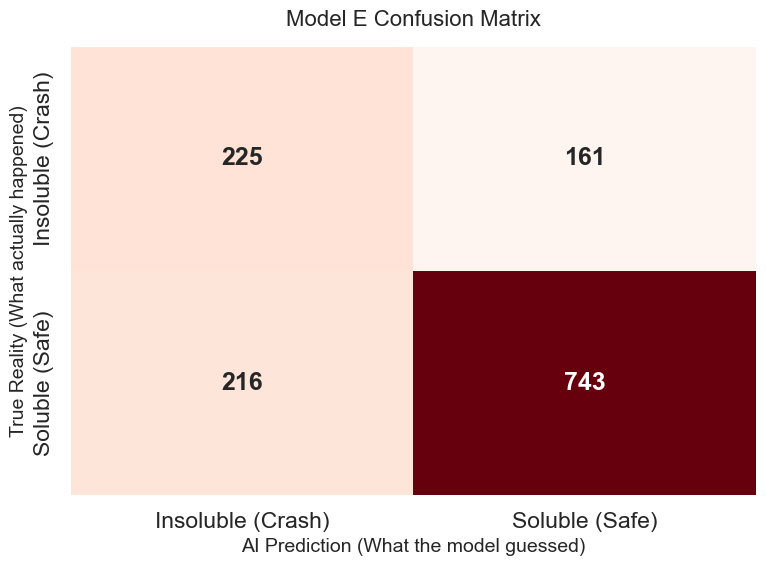

In [194]:
cm = confusion_matrix(y_test, y_pred_E)

plt.figure(figsize=(8, 6))
# Using a 'Reds' colormap to highlight the danger zones
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            yticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            annot_kws={"size": 18, "weight": "bold"})

plt.title('Model E Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('AI Prediction (What the model guessed)', fontsize=14)
plt.ylabel('True Reality (What actually happened)', fontsize=14)
plt.tight_layout()
plt.show()

In [199]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

honest_model, true_report = evaluate_by_solvent(df_desc, my_features, scale_weight)

,Solvent,Unseen_Molecules_Tested,True_Accuracy,True_Precision
0,ACN,186,54.30,72.48
1,MeOH,186,62.90,71.77
2,DCM,186,69.89,75.76
3,CHCl3,186,69.89,81.95
4,DMSO,186,75.27,84.81


In [60]:
def evaluate_ranking(name, X, idx, y_true):
    probas = model_E.predict_proba(X)[:, 1]

    results_df = pd.DataFrame({
        'SMILES':     df_desc.iloc[idx]['SMILES'].values,
        'Solvent':    df_desc.iloc[idx]['Solvent_Name'].values,
        'Actual':     y_true,
        'Confidence': probas
    })

    correct        = 0
    wrong_but_safe = 0
    critical_fail  = 0
    total          = 0

    for smiles, group in results_df.groupby('SMILES'):
        if group['Actual'].nunique() < 2:
            continue

        total += 1

        group_agg = group.groupby('Solvent').agg(
            Confidence=('Confidence', 'mean'),
            Actual=('Actual', 'max')
        ).reset_index()

        ranked = group_agg.sort_values('Confidence', ascending=False)

        top_is_soluble    = ranked.iloc[0]['Actual'] == 1
        soluble_conf      = group_agg[group_agg['Actual'] == 1]['Confidence']
        insoluble_conf    = group_agg[group_agg['Actual'] == 0]['Confidence']
        order_correct     = soluble_conf.min() > insoluble_conf.max()

        if order_correct:
            correct += 1
        elif top_is_soluble:
            wrong_but_safe += 1
        else:
            critical_fail += 1

        """print(f"\n{'='*55}")
        print(f"Molecule: {smiles}")
        print(f"{'─'*55}")
        print(f"  {'Rank':<6} {'Solvent':<12} {'Confidence':>12} {'Actual':>10}")
        print(f"{'─'*55}")
        for rank, (_, row) in enumerate(ranked.iterrows(), 1):
            actual_label = '✓ soluble' if row['Actual'] == 1 else '✗ insoluble'
            marker = '▶' if rank == 1 else ' '
            print(f"  {marker}{rank:<5} {row['Solvent']:<12} {row['Confidence']*100:>10.1f}%  {actual_label:>10}")"""

    print(f"\n{'='*55}")
    print(f"SUMMARY — {name}")
    print(f"{'='*55}")
    print(f"Total molecules evaluated:        {total}")
    print(f"Order fully correct:              {correct}  ({100*correct/total:.1f}%)")
    print(f"Wrong order but top pick safe:    {wrong_but_safe}  ({100*wrong_but_safe/total:.1f}%)")
    print(f"Critical failure (top insoluble): {critical_fail}  ({100*critical_fail/total:.1f}%)")
    return results_df

In [61]:
result_df_train = evaluate_ranking("TRAINING SET", X_train_df, train_idx, y_train)
results_df_val = evaluate_ranking("VALIDATION", X_val_df,   val_absolute_idx,   y_val)
results_df_test = evaluate_ranking("TEST SET",     X_test_df,  test_idx,  y_test)



SUMMARY — TRAINING SET
Total molecules evaluated:        57
Order fully correct:              32  (56.1%)
Wrong order but top pick safe:    16  (28.1%)
Critical failure (top insoluble): 9  (15.8%)

SUMMARY — VALIDATION
Total molecules evaluated:        12
Order fully correct:              6  (50.0%)
Wrong order but top pick safe:    4  (33.3%)
Critical failure (top insoluble): 2  (16.7%)

SUMMARY — TEST SET
Total molecules evaluated:        22
Order fully correct:              15  (68.2%)
Wrong order but top pick safe:    4  (18.2%)
Critical failure (top insoluble): 3  (13.6%)


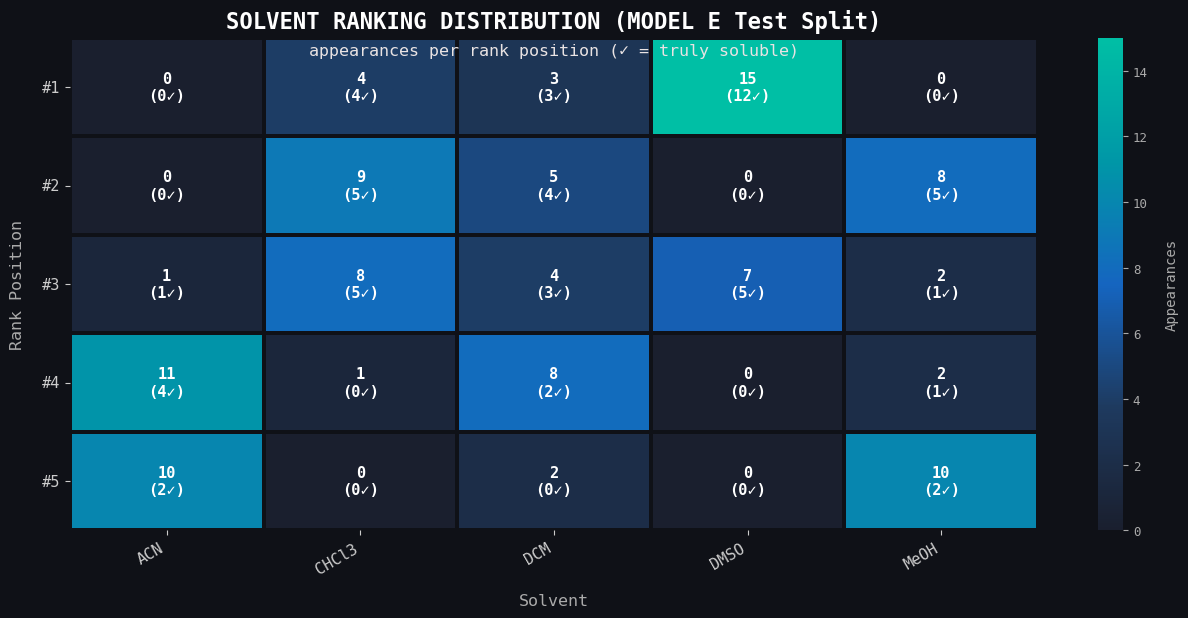

In [63]:
rank_records = []

for smiles, group in results_df_test.groupby('SMILES'):
    if group['Actual'].nunique() < 2:
        continue

    group_agg = group.groupby('Solvent').agg(
        Confidence=('Confidence', 'mean'),
        Actual=('Actual', 'max')
    ).reset_index()

    ranked = group_agg.sort_values('Confidence', ascending=False).reset_index(drop=True)

    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        rank_records.append({
            'Solvent': row['Solvent'],
            'Rank': rank,
            'Correct':  int(row['Actual'] == 1)  # 1 if soluble, 0 if insoluble
        })

rank_df = pd.DataFrame(rank_records)

# ranking count
solvents = sorted(rank_df['Solvent'].unique())
ranks    = sorted(rank_df['Rank'].unique())

count_matrix = rank_df.groupby(['Rank', 'Solvent']).size().unstack(fill_value=0)
correct_matrix = rank_df.groupby(['Rank', 'Solvent'])['Correct'].sum().unstack(fill_value=0)

annot_matrix = count_matrix.copy().astype(str)
for rank in count_matrix.index:
    for solvent in count_matrix.columns:
        total   = count_matrix.loc[rank, solvent]
        correct = correct_matrix.loc[rank, solvent]
        annot_matrix.loc[rank, solvent] = f"{total}\n({correct}✓)"


# Styling, might as well do some
plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

# Custom dark colormap
from matplotlib.colors import LinearSegmentedColormap
dark_cmap = LinearSegmentedColormap.from_list(
    'dark_chem', ['#1a1f2e', '#1e3a5f', '#1565c0', '#0097a7', '#00bfa5'], N=256
)

sns.heatmap(
    count_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=dark_cmap,
    linewidths=1.5,
    linecolor='#0f1117',
    ax=ax,
    cbar=True,
    annot_kws={'size': 11, 'color': 'white', 'fontfamily': 'monospace', 'fontweight': 'bold'}
)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
cbar.outline.set_edgecolor('#333333')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa', fontsize=9)
cbar.set_label('Appearances', color='#aaaaaa', fontsize=10, labelpad=12)

# Style axes
ax.tick_params(colors='#cccccc', labelsize=11)
ax.set_xlabel('Solvent', color='#aaaaaa', fontsize=12, labelpad=12)
ax.set_ylabel('Rank Position', color='#aaaaaa', fontsize=12, labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

# Rank labels
ax.set_yticklabels(
    [f'#{i}' for i in count_matrix.index],
    rotation=0, color='#cccccc', fontsize=11
)
ax.set_xticklabels(
    count_matrix.columns,
    rotation=30, ha='right', color='#cccccc', fontsize=11
)

# Title
fig.text(0.5, 1.01, 'SOLVENT RANKING DISTRIBUTION (MODEL E Test Split)',
         ha='center', va='bottom', fontsize=16,
         color='white', fontfamily='monospace', fontweight='bold', transform=ax.transAxes)
fig.text(0.5, 0.96, 'appearances per rank position (✓ = truly soluble)',
         ha='center', va='bottom', fontsize=12,
         color="#E9E3E3", fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.show()

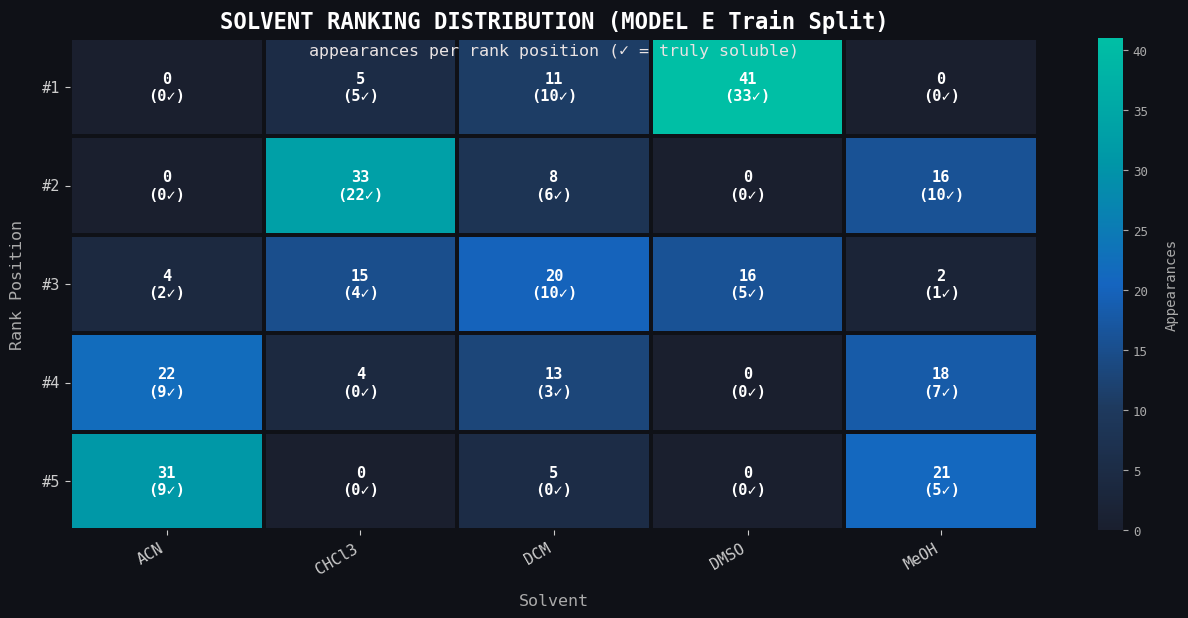

In [65]:
rank_records = []

for smiles, group in result_df_train.groupby('SMILES'):
    if group['Actual'].nunique() < 2:
        continue

    group_agg = group.groupby('Solvent').agg(
        Confidence=('Confidence', 'mean'),
        Actual=('Actual', 'max')
    ).reset_index()

    ranked = group_agg.sort_values('Confidence', ascending=False).reset_index(drop=True)

    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        rank_records.append({
            'Solvent': row['Solvent'],
            'Rank': rank,
            'Correct':  int(row['Actual'] == 1)  # 1 if soluble, 0 if insoluble
        })

rank_df = pd.DataFrame(rank_records)

# ranking count
solvents = sorted(rank_df['Solvent'].unique())
ranks    = sorted(rank_df['Rank'].unique())

count_matrix = rank_df.groupby(['Rank', 'Solvent']).size().unstack(fill_value=0)
correct_matrix = rank_df.groupby(['Rank', 'Solvent'])['Correct'].sum().unstack(fill_value=0)

annot_matrix = count_matrix.copy().astype(str)
for rank in count_matrix.index:
    for solvent in count_matrix.columns:
        total   = count_matrix.loc[rank, solvent]
        correct = correct_matrix.loc[rank, solvent]
        annot_matrix.loc[rank, solvent] = f"{total}\n({correct}✓)"


# Styling, might as well do some
plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

# Custom dark colormap
from matplotlib.colors import LinearSegmentedColormap
dark_cmap = LinearSegmentedColormap.from_list(
    'dark_chem', ['#1a1f2e', '#1e3a5f', '#1565c0', '#0097a7', '#00bfa5'], N=256
)

sns.heatmap(
    count_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=dark_cmap,
    linewidths=1.5,
    linecolor='#0f1117',
    ax=ax,
    cbar=True,
    annot_kws={'size': 11, 'color': 'white', 'fontfamily': 'monospace', 'fontweight': 'bold'}
)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
cbar.outline.set_edgecolor('#333333')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa', fontsize=9)
cbar.set_label('Appearances', color='#aaaaaa', fontsize=10, labelpad=12)

# Style axes
ax.tick_params(colors='#cccccc', labelsize=11)
ax.set_xlabel('Solvent', color='#aaaaaa', fontsize=12, labelpad=12)
ax.set_ylabel('Rank Position', color='#aaaaaa', fontsize=12, labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

# Rank labels
ax.set_yticklabels(
    [f'#{i}' for i in count_matrix.index],
    rotation=0, color='#cccccc', fontsize=11
)
ax.set_xticklabels(
    count_matrix.columns,
    rotation=30, ha='right', color='#cccccc', fontsize=11
)

# Title
fig.text(0.5, 1.01, 'SOLVENT RANKING DISTRIBUTION (MODEL E Train Split)',
         ha='center', va='bottom', fontsize=16,
         color='white', fontfamily='monospace', fontweight='bold', transform=ax.transAxes)
fig.text(0.5, 0.96, 'appearances per rank position (✓ = truly soluble)',
         ha='center', va='bottom', fontsize=12,
         color="#E9E3E3", fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.show()

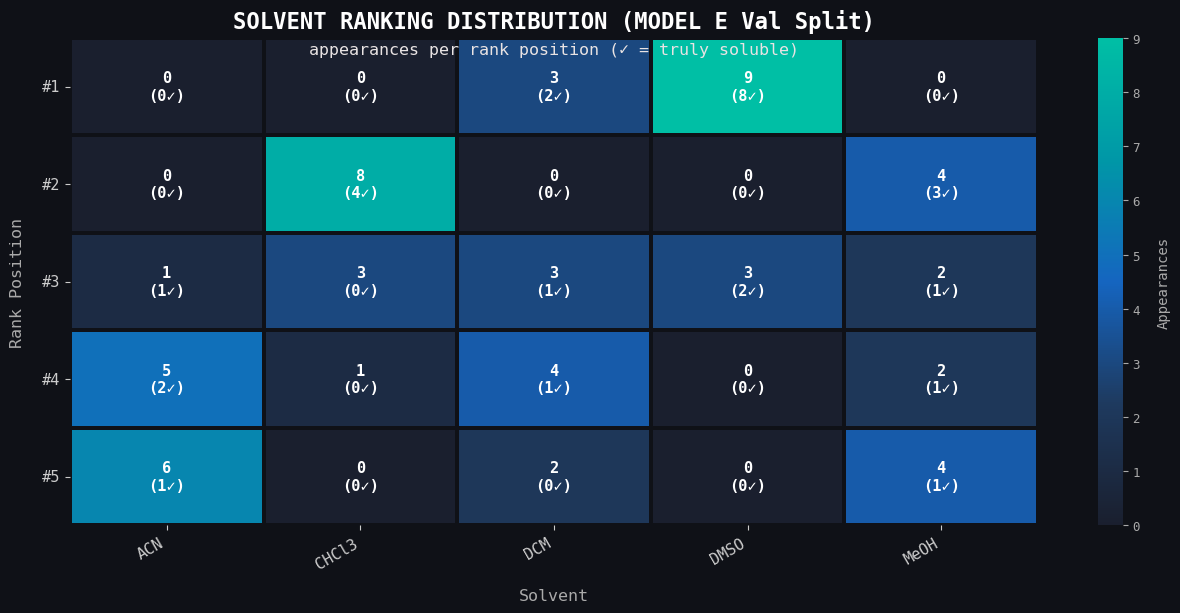

In [66]:
rank_records = []

for smiles, group in results_df_val.groupby('SMILES'):
    if group['Actual'].nunique() < 2:
        continue

    group_agg = group.groupby('Solvent').agg(
        Confidence=('Confidence', 'mean'),
        Actual=('Actual', 'max')
    ).reset_index()

    ranked = group_agg.sort_values('Confidence', ascending=False).reset_index(drop=True)

    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        rank_records.append({
            'Solvent': row['Solvent'],
            'Rank': rank,
            'Correct':  int(row['Actual'] == 1)  # 1 if soluble, 0 if insoluble
        })

rank_df = pd.DataFrame(rank_records)

# ranking count
solvents = sorted(rank_df['Solvent'].unique())
ranks    = sorted(rank_df['Rank'].unique())

count_matrix = rank_df.groupby(['Rank', 'Solvent']).size().unstack(fill_value=0)
correct_matrix = rank_df.groupby(['Rank', 'Solvent'])['Correct'].sum().unstack(fill_value=0)

annot_matrix = count_matrix.copy().astype(str)
for rank in count_matrix.index:
    for solvent in count_matrix.columns:
        total   = count_matrix.loc[rank, solvent]
        correct = correct_matrix.loc[rank, solvent]
        annot_matrix.loc[rank, solvent] = f"{total}\n({correct}✓)"


# Styling, might as well do some
plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

# Custom dark colormap
from matplotlib.colors import LinearSegmentedColormap
dark_cmap = LinearSegmentedColormap.from_list(
    'dark_chem', ['#1a1f2e', '#1e3a5f', '#1565c0', '#0097a7', '#00bfa5'], N=256
)

sns.heatmap(
    count_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=dark_cmap,
    linewidths=1.5,
    linecolor='#0f1117',
    ax=ax,
    cbar=True,
    annot_kws={'size': 11, 'color': 'white', 'fontfamily': 'monospace', 'fontweight': 'bold'}
)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
cbar.outline.set_edgecolor('#333333')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa', fontsize=9)
cbar.set_label('Appearances', color='#aaaaaa', fontsize=10, labelpad=12)

# Style axes
ax.tick_params(colors='#cccccc', labelsize=11)
ax.set_xlabel('Solvent', color='#aaaaaa', fontsize=12, labelpad=12)
ax.set_ylabel('Rank Position', color='#aaaaaa', fontsize=12, labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

# Rank labels
ax.set_yticklabels(
    [f'#{i}' for i in count_matrix.index],
    rotation=0, color='#cccccc', fontsize=11
)
ax.set_xticklabels(
    count_matrix.columns,
    rotation=30, ha='right', color='#cccccc', fontsize=11
)

# Title
fig.text(0.5, 1.01, 'SOLVENT RANKING DISTRIBUTION (MODEL E Val Split)',
         ha='center', va='bottom', fontsize=16,
         color='white', fontfamily='monospace', fontweight='bold', transform=ax.transAxes)
fig.text(0.5, 0.96, 'appearances per rank position (✓ = truly soluble)',
         ha='center', va='bottom', fontsize=12,
         color="#E9E3E3", fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.show()

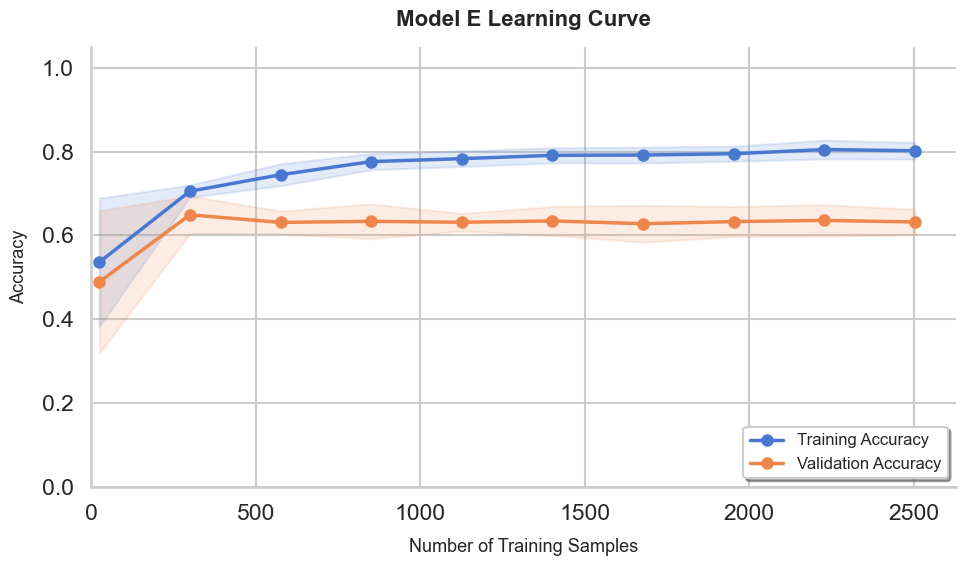

In [190]:
sns.set_theme(style="whitegrid", palette="muted", context="talk")


shuffle_idx = np.random.permutation(len(y_train))
X_shuf = X_train_E_best[shuffle_idx]
y_shuf = y_train[shuffle_idx]
groups_train = df_desc.iloc[train_idx]['SMILES']
groups_shuf = groups_train.iloc[shuffle_idx].values

gkf = GroupKFold(n_splits=5)
train_sizes, train_scores, test_scores = learning_curve(
        model_E, X_shuf, y_shuf, cv=gkf, groups=groups_shuf, n_jobs=-1, 
        train_sizes=np.linspace(0.01, 1 , 10), scoring='accuracy'
    )
    
train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color="C0", linewidth=2.5, markersize=8, label="Training Accuracy")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="C0")

ax.plot(train_sizes, test_mean, 'o-', color="C1", linewidth=2.5, markersize=8, label="Validation Accuracy")
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="C1")

ax.set_title("Model E Learning Curve", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Number of Training Samples", fontsize=13, labelpad=10)
ax.set_ylabel("Accuracy", fontsize=13, labelpad=10)

sns.despine(ax=ax)
    
ax.legend(loc="lower right", frameon=True, fancybox=True, shadow=True, fontsize=12)

ax.set_xlim(left=0)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [161]:
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_E = ['RT'] + cols_E + list_matrix_vectors

imp_E = pd.DataFrame({'Feature': selected_names_E, 'Importance': model_E.feature_importances_})

print(" MODEL E FEATURE IMPORTANCES:")
print(imp_E.sort_values(by='Importance', ascending=False).to_string(index=False))

 MODEL E FEATURE IMPORTANCES:
          Feature  Importance
            MolWt    0.178054
     Sol_Hansen_D    0.099816
               RT    0.094097
   Sol_Dielectric    0.088626
     Sol_Hansen_H    0.073967
     Sol_Hansen_P    0.072737
 Matrix_Vector_M7    0.047013
Matrix_Vector_M10    0.043621
 Matrix_Vector_M8    0.042232
 Matrix_Vector_M9    0.041381
 Matrix_Vector_M4    0.038900
 Matrix_Vector_M3    0.037607
 Matrix_Vector_M1    0.037396
 Matrix_Vector_M6    0.036484
 Matrix_Vector_M5    0.035385
 Matrix_Vector_M2    0.032683


<Figure size 1100x600 with 0 Axes>

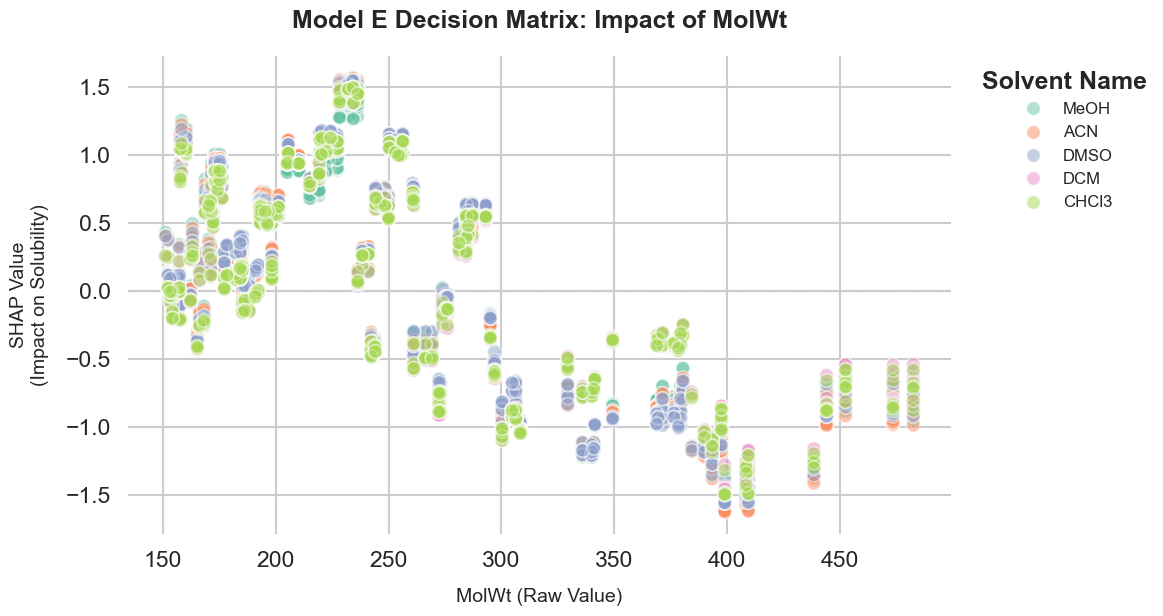

In [196]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# PLOT 1: Let's see how Molecular Weight interacts with the actual Machine Names
# (Assuming your column is named 'Matrix ID Name')
plot_custom_shap_categorical(model_E, df_desc, my_features, 
                             base_feature='MolWt', 
                             color_col='Solvent_Name')

<Figure size 1100x600 with 0 Axes>

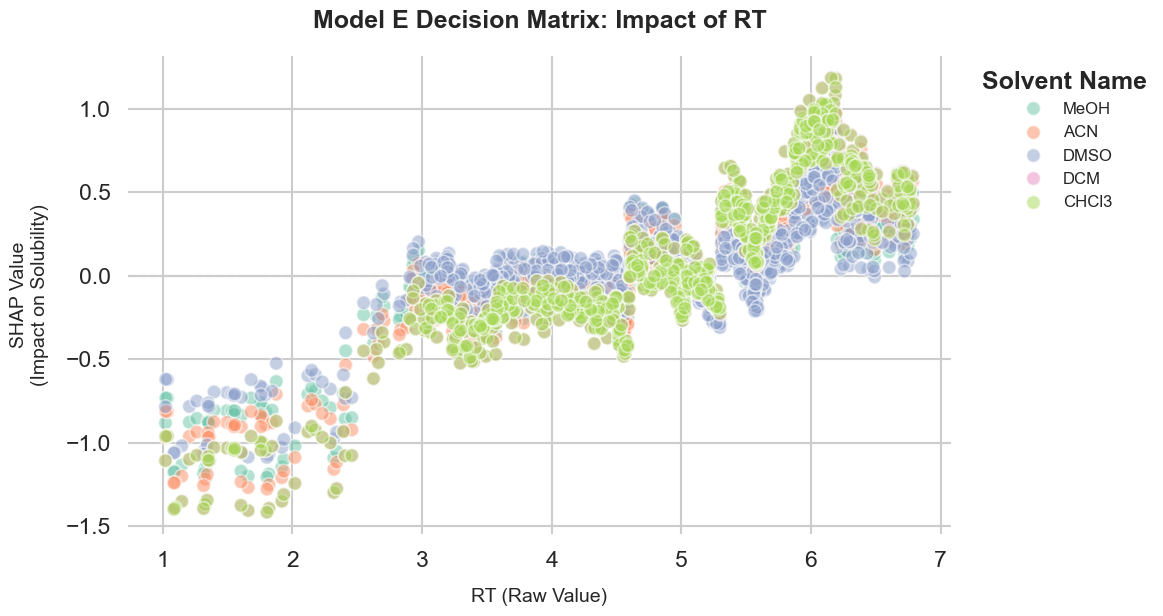

In [197]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# PLOT 1: Let's see how Molecular Weight interacts with the actual Machine Names
# (Assuming your column is named 'Matrix ID Name')
plot_custom_shap_categorical(model_E, df_desc, my_features, 
                             base_feature='RT', 
                             color_col='Solvent_Name')

In [203]:
def plot_solvent_gallery_shap(model, X_matrix, df_test, feature_names, base_feature='MolWt', color_col='Matrix ID Name'):
    """
    Generates a separate SHAP plot for every unique solvent in the test set.
    """
    # 1. Initialize the Explainer once
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer.shap_values(X_matrix)
    
    # Get the index of the feature we want to plot (e.g., 'MolWt')
    feature_idx = feature_names.index(base_feature)
    
    # 2. Identify unique solvents
    solvents = df_test['Solvent_Name'].unique()
    
    for sol in solvents:
        # Find the rows belonging to THIS solvent
        sol_mask = (df_test['Solvent_Name'] == sol).values
        
        # Pull out the specific SHAP values and raw values for this solvent
        sol_shap = shap_values_all[sol_mask, feature_idx]
        sol_raw_val = X_matrix[sol_mask, feature_idx]
        sol_color = df_test.iloc[sol_mask][color_col].values 
        
        # Packaging the masked data into a tiny temporary dataframe makes Seaborn much happier!
        plot_df = pd.DataFrame({
            'Raw_Value': sol_raw_val,
            'SHAP_Value': sol_shap,
            'Color_Label': sol_color
        })
        
        # Create the Plot
        fig, ax = plt.subplots(figsize=(10, 5.5))
        
        # The Modern Scatterplot
        sns.scatterplot(
            data=plot_df,
            x='Raw_Value', 
            y='SHAP_Value', 
            hue='Color_Label', 
            palette='Set2',      # Premium categorical palette
            alpha=0.6,           # Perfect transparency for overlapping clusters
            s=110,               # Large, readable dots
            edgecolor='white',   # Crisp white separation borders
            linewidth=1.2,
            ax=ax
        )
        
        # Clean Baseline (Forced to the background with zorder=0)
        ax.axhline(0, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.4, zorder=0)
        
        # Typography & Spacing
        ax.set_title(f"SHAP: Impact of {base_feature} in {sol}", fontsize=17, fontweight='bold', pad=13)
        ax.set_xlabel(f"{base_feature} (Raw Value)", fontsize=13, fontweight='bold', labelpad=10)
        ax.set_ylabel("SHAP Value\n(Impact on Solubility)", fontsize=13, fontweight='bold', labelpad=10)
        
        # Floating Legend
        legend = ax.legend(
            title=color_col.replace('_', ' ').title(), 
            bbox_to_anchor=(1.02, 1), 
            loc='upper left',
            frameon=False, 
            fontsize=11
        )
        legend.get_title().set_fontweight('bold')
        
        # Despine to remove harsh box lines
        sns.despine(ax=ax, left=True, bottom=True)
        
        plt.tight_layout()
        plt.show()

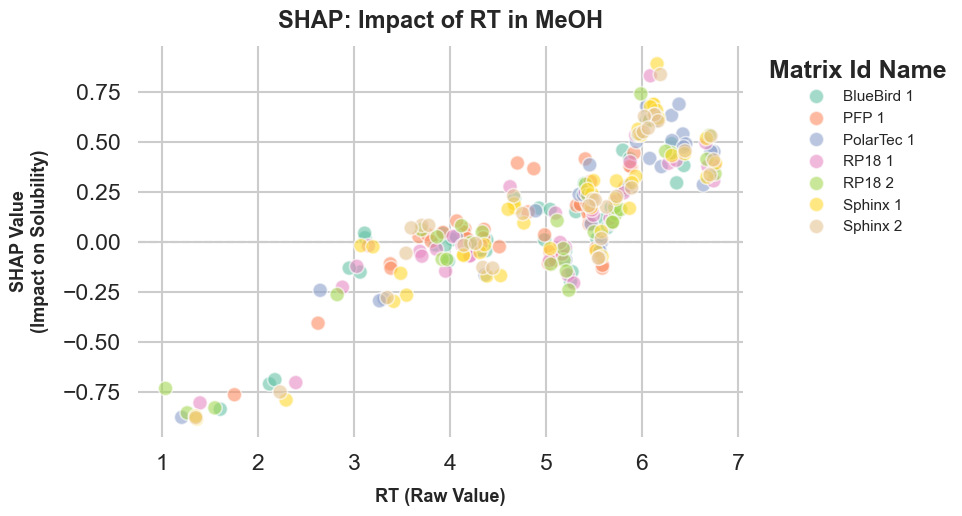

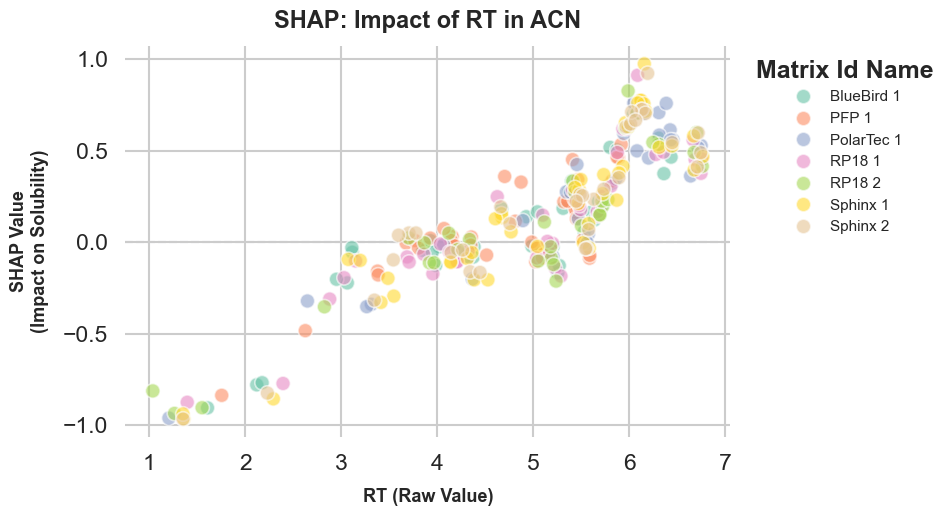

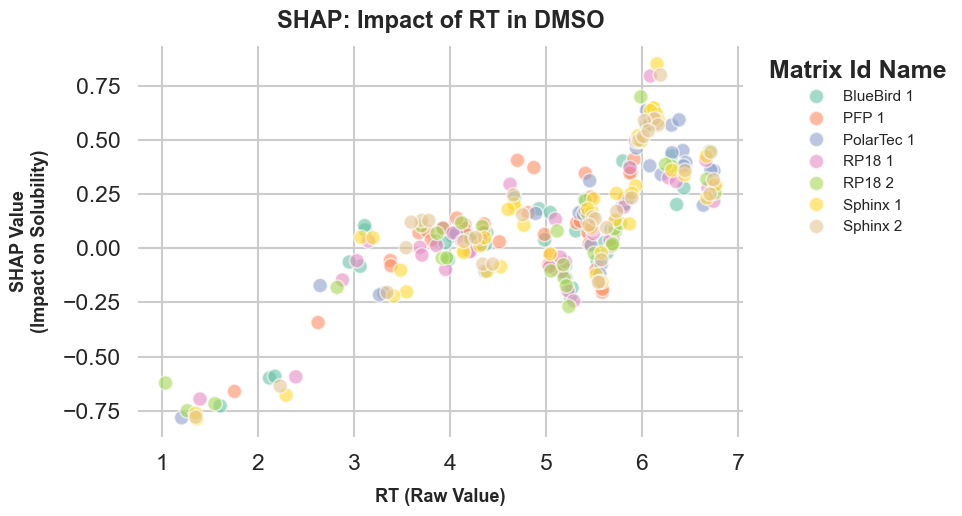

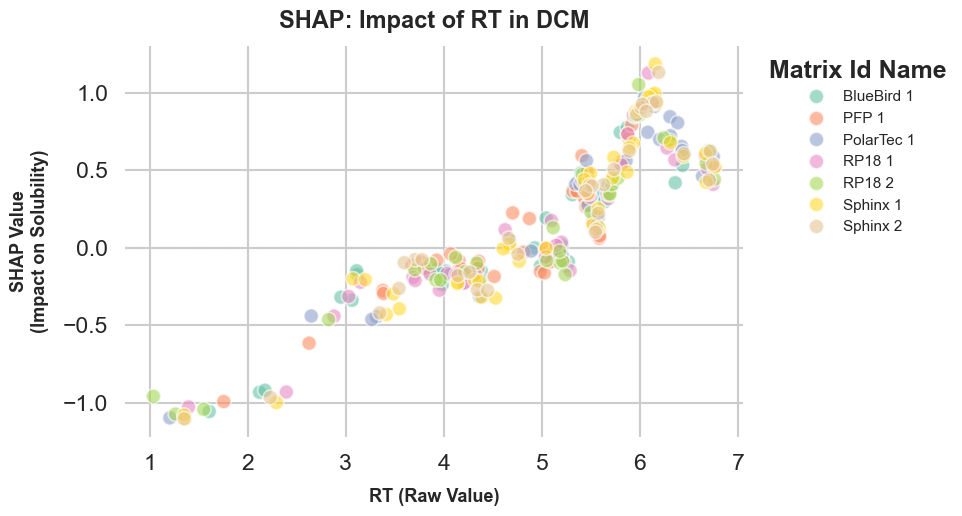

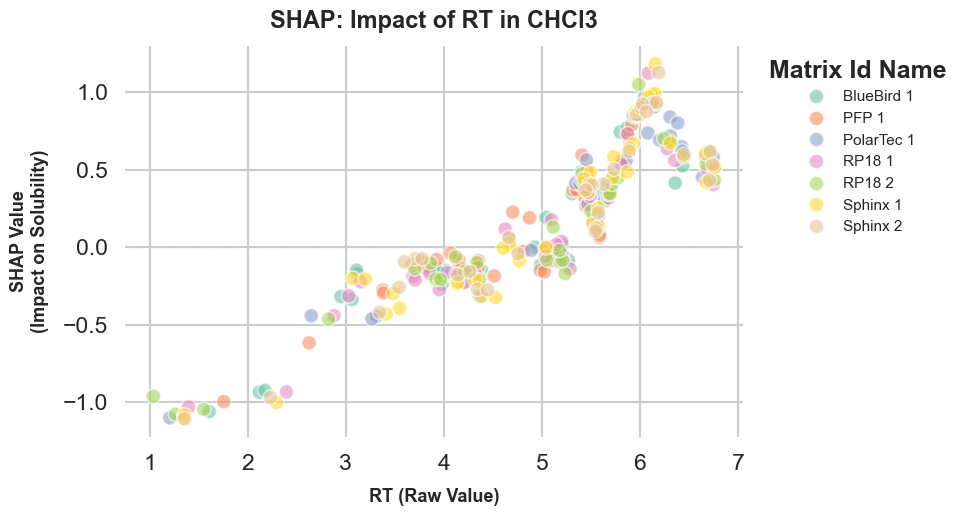

In [204]:
feature_names_E = ['RT'] + cols_E + [f"M_{i}" for i in range(X_mat.shape[1])]

plot_solvent_gallery_shap(
    model=model_E, 
    X_matrix=X_test_E_best, 
    df_test=df_desc.iloc[test_idx], # The dataframe version of your test set
    feature_names=feature_names_E,
    base_feature='RT'
)

In [34]:
def export_confidence_scores(loaded_model, df, phys_feature_list, output_filename="Model_Confidence_Scores.xlsx"):
    
    # --- 1. REBUILD THE EXACT FEATURE MATRIX ---
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    # --- 2. GET THE PREDICTIONS AND PROBABILITIES ---
    # .predict() gives the hard 1 or 0
    predictions = loaded_model.predict(X_final)
    
    # .predict_proba() gives an array with two numbers per row:
    # [Probability of 0, Probability of 1]
    # We want the second column (index 1), which is the % chance of being Soluble.
    probabilities = loaded_model.predict_proba(X_final)[:, 1] 
    
    # --- 3. BUILD A CLEAN DATAFRAME FOR EXCEL ---
    # We are picking the most important columns to look at in Excel
    # (Assuming your molecule names/SMILES are in a column called 'SMILES')
    results_df = pd.DataFrame({
        'Molecule_SMILES': df['SMILES'],           # Change 'SMILES' if your ID column is named differently
        'Matrix_Machine': df['Matrix ID Name'],    # Just to see which machine it ran on
        'Retention_Time': df['RT'],
        'Actual_Solubility': df['Soluble'],        # What actually happened in the lab (0 or 1)
        'AI_Predicted_Class': predictions,         # What the AI guessed (0 or 1)
        'AI_Confidence_Score': probabilities       # The raw % score!
    })
    
    # --- 4. ADD A HELPFUL 'STATUS' COLUMN ---
    # Let's write a quick loop to label exactly what happened for easier sorting in Excel
    conditions = [
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 0),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 0)
    ]
    choices = ['True Positive (Correct)', 'True Negative (Correct)', 
               'False Positive (Danger)', 'False Negative (Missed)']
    results_df['Result_Type'] = np.select(conditions, choices, default='Unknown')
    
    # --- 5. EXPORT TO EXCEL ---
    print(f"Saving to {output_filename}")
    
    # Save as Excel (you can also use .to_csv('filename.csv', index=False) if you prefer)
    results_df.to_excel(output_filename, index=False)
    
    return results_df

In [35]:
df_results = export_confidence_scores(my_model, df_desc, my_features)

Saving to Model_Confidence_Scores.xlsx


In [27]:
matrix_vectors_df = pd.DataFrame(
    df_desc['Matrix_Packed_Array'].tolist(),
    # We dynamically name them Matrix_Vector_1, Matrix_Vector_2, etc.
    columns=[f"Matrix_Vector_{i+1}" for i in range(len(df_desc['Matrix_Packed_Array'].iloc[0]))]
)

df_desc = pd.concat([df_desc.reset_index(drop=True), matrix_vectors_df.reset_index(drop=True)], axis=1)

In [219]:
cat_cols = ['Solvent_Name', 'Matrix ID Name']
cont_cols = ['RT', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H'] 
vector_cols = matrix_vectors_df.columns.tolist()
all_cols = cont_cols + vector_cols + cat_cols

In [220]:
# We slice the original dataframe using the exact same train_idx/test_idx you made
X_train_cb = df_desc.iloc[train_idx][all_cols].copy()
y_train_cb = df_desc.iloc[train_idx]['Soluble'].copy()

X_test_cb = df_desc.iloc[test_idx][all_cols].copy()
y_test_cb = df_desc.iloc[test_idx]['Soluble'].copy()

# CatBoost can handle raw text, but it hates Python 'NaN' or None values in categorical columns.
X_train_cb[cat_cols] = X_train_cb[cat_cols].fillna('Missing')
X_test_cb[cat_cols] = X_test_cb[cat_cols].fillna('Missing')

# Carving a validation set out of the training data
# GroupShuffleSplit by SMILES so molecules doesn't leak between val and train
val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=99)
groups_train = df_desc.iloc[train_idx]['SMILES'].values

sub_train_idx, val_idx = next(val_splitter.split(
    X_train_cb, y_train_cb, groups=groups_train
))

X_tr    = X_train_cb.iloc[sub_train_idx]
y_tr    = y_train_cb.iloc[sub_train_idx]

X_val_cb   = X_train_cb.iloc[val_idx]      # validation: for early stopping only
y_val_cb   = y_train_cb.iloc[val_idx]


model_cb = CatBoostClassifier(
    iterations=500,           # maximum number of trees the AI is allowed to build    
    depth=8,                 # variables the AI can combine into a single "thought." A depth of 2 means "If heavy AND in DCM"
    learning_rate= 0.01,
    cat_features=cat_cols, 
    eval_metric='AUC',
    random_seed=76,
    l2_leaf_reg=15,
    verbose=0,
    min_data_in_leaf=10
)

model_cb.fit(X_tr, y_tr,eval_set=(X_test_cb, y_test_cb))

y_pred_cb = model_cb.predict(X_test_cb)

print(f"Accuracy:  {accuracy_score(y_test_cb, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test_cb, y_pred_cb, zero_division=0):.4f}\n")

Accuracy:  0.7257
Precision: 0.7543



In [17]:
# 1. BUILD THE GRADING DATAFRAME
# We map CatBoost's predictions directly back to the physical solvent names
results_cb_df = pd.DataFrame({
    'Solvent': X_test_cb['Solvent_Name'],
    'Actual': y_test_cb.values,            # The real lab result
    'Predicted': y_pred_cb                 # What CatBoost guessed
})

# 2. CALCULATE THE GRADES
cb_solvent_grades = []

for solvent, group in results_cb_df.groupby('Solvent'):
    acc = accuracy_score(group['Actual'], group['Predicted'])
    prec = precision_score(group['Actual'], group['Predicted'], zero_division=0) 
    
    cb_solvent_grades.append({
        'Solvent': solvent,
        'Unseen_Molecules_Tested': len(group),
        'CatBoost_Accuracy': round(acc * 100, 2),
        'CatBoost_Precision': round(prec * 100, 2)
    })
    
# 3. FORMAT AND DISPLAY
cb_report_card = pd.DataFrame(cb_solvent_grades)
cb_report_card = cb_report_card.sort_values(by='CatBoost_Accuracy', ascending=True).reset_index(drop=True)

print("📋 THE FINAL CATBOOST REPORT CARD (Unseen Test Data):")
display(cb_report_card)

📋 THE FINAL CATBOOST REPORT CARD (Unseen Test Data):


,Solvent,Unseen_Molecules_Tested,CatBoost_Accuracy,CatBoost_Precision
0,MeOH,269,55.76,63.30
1,ACN,269,58.74,64.67
2,DCM,269,59.48,70.51
3,CHCl3,269,72.49,79.74
4,DMSO,269,78.81,83.68


In [58]:
cb_importances = model_cb.get_feature_importance()
imp_cb = pd.DataFrame({
    'Feature': X_train_cb.columns, 
    'Importance': cb_importances
})

# Sort and display
display(imp_cb.sort_values(by='Importance', ascending=False).reset_index(drop=True))

,Feature,Importance
0,MolWt,51.936608
1,RT,18.759443
2,Sol_Hansen_D,5.298576
3,Sol_Hansen_P,4.940308
4,Sol_Dielectric,4.531971
5,Sol_Hansen_H,3.096873
6,Solvent_Name,2.985959
7,Matrix ID Name,2.050498
8,Matrix_Vector_10,0.893986
9,Matrix_Vector_5,0.857433


In [265]:
def plot_catboost_shap_categorical(model, df, all_cols, cat_cols, base_feature='MolWt', color_col='Matrix ID Name'):

    
    # We extract the exact columns and fill missing text values so CatBoost doesn't panic
    X_shap = df[all_cols].copy()
    X_shap[cat_cols] = X_shap[cat_cols].fillna('Missing')
    
    # We must wrap the data in a CatBoost 'Pool' so it knows which columns are text
    pool = catboost.Pool(data=X_shap, cat_features=cat_cols)
    
    # --- 2. EXTRACT SHAP NATIVELY ---
    # This uses CatBoost's internal C++ engine. It is lightning fast!
    shap_values_raw = model.get_feature_importance(pool, type='ShapValues')
    
    # CatBoost returns a matrix where the very last column is the "Base Expected Value"
    # We slice off the last column ( [:, :-1] ) to leave only the actual feature impacts
    shap_values = shap_values_raw[:, :-1] 
    
    # --- 3. ISOLATE THE FEATURE WE WANT TO PLOT ---
    feature_idx = all_cols.index(base_feature)
    specific_shap_values = shap_values[:, feature_idx]
    
    # --- 4. BUILD A CLEAN DATAFRAME FOR SEABORN ---
    plot_df = pd.DataFrame({
        base_feature: X_shap[base_feature],
        'SHAP Value': specific_shap_values,
        color_col: X_shap[color_col]
    })
    
    # --- 5. RENDER THE PLOT ---
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=plot_df, 
        x=base_feature, 
        y='SHAP Value', 
        hue=color_col, 
        palette='tab10',   # A distinct color palette
        alpha=0.7,         # Makes the dots slightly transparent so we can see overlaps
        edgecolor=None
    )
    
    # Draw the baseline at 0.0
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Clean up the visuals
    plt.title(f"CatBoost SHAP: Impact of {base_feature} by {color_col}", fontsize=14, pad=15)
    plt.xlabel(base_feature, fontsize=12)
    plt.ylabel('SHAP Value (Impact on predicted Soluble)', fontsize=12)
    
    # Move the legend outside the plot so it doesn't cover up data
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=color_col)
    plt.tight_layout()
    plt.show()



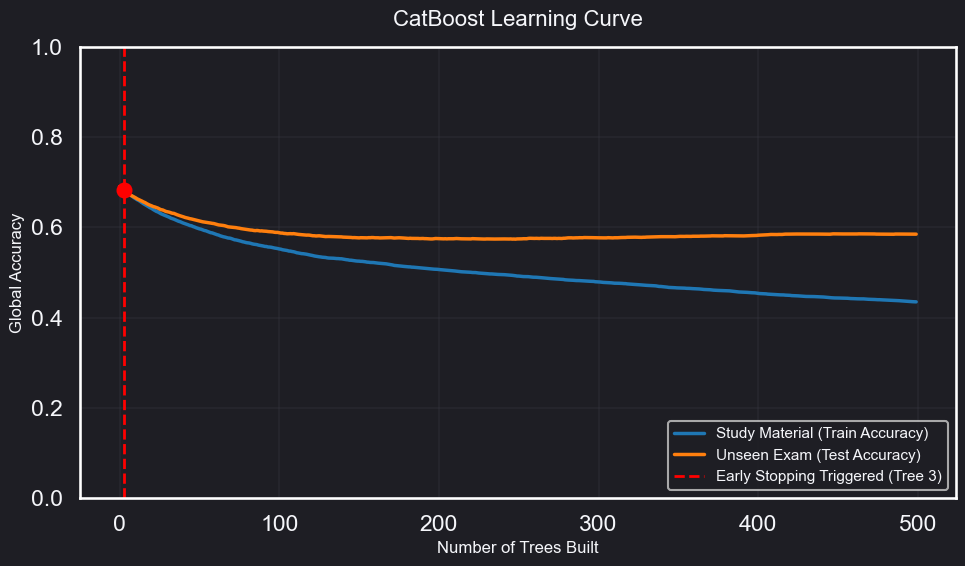

In [221]:
history = model_cb.evals_result_

# 2. Pull the specific accuracy arrays
train_error = history['learn']['Logloss']
test_error = history['validation']['Logloss']

# 3. Find the exact tree where the AI peaked before overfitting
best_tree = model_cb.get_best_iteration()

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot the curves
plt.plot(train_error, label='Study Material (Train Accuracy)', color='#1f77b4', linewidth=2.5)
plt.plot(test_error, label='Unseen Exam (Test Accuracy)', color='#ff7f0e', linewidth=2.5)

# Draw the "Emergency Brake" line
if best_tree is not None:
    plt.axvline(x=best_tree, color='red', linestyle='--', linewidth=2,
                label=f'Early Stopping Triggered (Tree {best_tree})')
    # Mark the peak point
    plt.scatter(best_tree, test_error[best_tree], color='red', s=100, zorder=5)

# Clean up visuals
plt.ylim(0, 1)
plt.title('CatBoost Learning Curve', fontsize=16, pad=15)
plt.xlabel('Number of Trees Built', fontsize=12)
plt.ylabel('Global Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

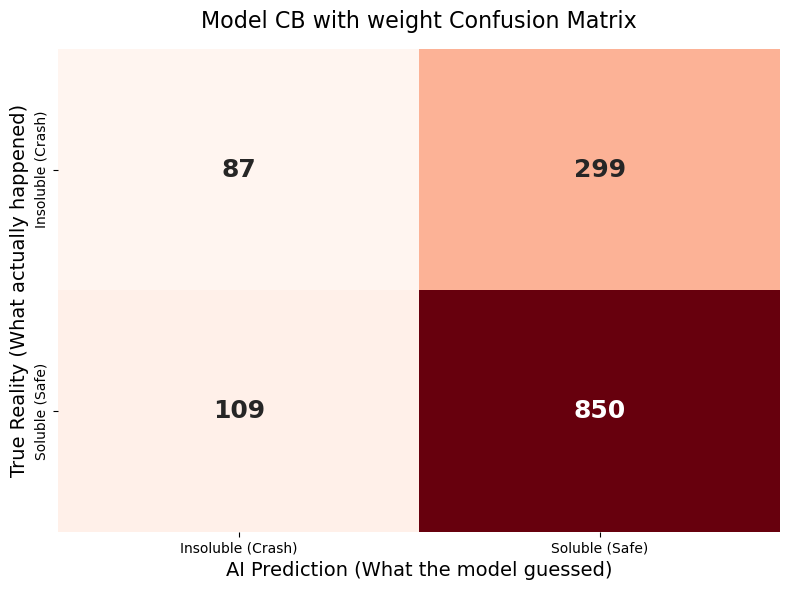

In [76]:
cm = confusion_matrix(y_test_cb, y_pred_cb)

plt.figure(figsize=(8, 6))
# Using a 'Reds' colormap to highlight the danger zones
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            yticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            annot_kws={"size": 18, "weight": "bold"})

plt.title('Model CB with weight Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('AI Prediction (What the model guessed)', fontsize=14)
plt.ylabel('True Reality (What actually happened)', fontsize=14)
plt.tight_layout()
plt.show()

In [78]:
print(df_desc['Soluble'].value_counts())
print(f"\nTotal soluble:   {(df_desc['Soluble'] == 1).sum()}")
print(f"Total insoluble: {(df_desc['Soluble'] == 0).sum()}")

Soluble
1    3037
0    1438
Name: count, dtype: int64

Total soluble:   3037
Total insoluble: 1438


In [77]:
# Check false positives broken down by solvent
results_df = pd.DataFrame({
    'Solvent': df_desc.iloc[test_idx]['Solvent_Name'],
    'Actual': y_test_cb,
    'Predicted': model_cb.predict(X_test_cb)
})

fp_by_solvent = results_df[
    (results_df['Predicted'] == 1) & (results_df['Actual'] == 0)
].groupby('Solvent').size().sort_values(ascending=False)

print(fp_by_solvent)

Solvent
DCM      68
MeOH     68
ACN      67
CHCl3    57
DMSO     39
dtype: int64


In [226]:
def run_bin_analysis(df_test, y_true, y_pred, feature_name, num_bins=8):

    
    # Create a DataFrame for analysis
    results = pd.DataFrame({
        'Feature_Value': df_test[feature_name].values,
        'Actual': y_true,
        'Predicted': y_pred
    })
    
    # Chop the continuous feature into bins
    results['Bin'] = pd.cut(results['Feature_Value'], bins=num_bins)
    
    # Calculate metrics per bin
    bin_stats = []
    for bin_interval, group in results.groupby('Bin', observed=False):
        if len(group) == 0:
            continue
            
        acc = accuracy_score(group['Actual'], group['Predicted'])
        errors = len(group) - sum(group['Actual'] == group['Predicted'])
        
        bin_stats.append({
            'Bin_Range': str(bin_interval),
            'Bin_Center': bin_interval.mid,
            'Total_Molecules': len(group),
            'Errors': errors,
            'Accuracy': acc * 100
        })
        
    stats_df = pd.DataFrame(bin_stats)
    
    custom_dark_params = {
        "axes.facecolor": "#1e1e24",       # Sleek dark charcoal background
        "figure.facecolor": "#1e1e24",     # Matches the figure edges
        "grid.color": "#383840",           # Subtle, non-distracting grid lines
        "text.color": "#f5f6fa",           # Soft off-white text for readability
        "axes.labelcolor": "#f5f6fa",
        "xtick.color": "#f5f6fa",
        "ytick.color": "#f5f6fa"
    }
    sns.set_theme(style="darkgrid", context="talk", rc=custom_dark_params)
    
    fig, ax1 = plt.subplots(figsize=(12, 6.5))
    
    # 2. Background Bar Chart (Sample Size)
    sns.barplot(
        data=stats_df, 
        x='Bin_Range', 
        y='Total_Molecules', 
        color='#455a64', # Muted slate grey/blue so it sits quietly in the background
        alpha=0.6, 
        edgecolor='none',
        ax=ax1
    )
    ax1.set_ylabel('Number of Molecules in Bin', color='#90a4ae', fontsize=13, fontweight='bold', labelpad=12)
    ax1.tick_params(axis='y', labelcolor='#90a4ae')
    ax1.set_xlabel(f'{feature_name} Bins', fontsize=13, fontweight='bold', labelpad=12)
    
    # Rotate X-axis labels and anchor them perfectly so they don't look messy
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    
    # 3. Foreground Line Chart (Accuracy)
    ax2 = ax1.twinx()
    
    # Turn off the ax2 grid so it doesn't cross over the ax1 grid and make a mess!
    ax2.grid(False) 
    
    sns.lineplot(
        data=stats_df, 
        x='Bin_Range', 
        y='Accuracy', 
        color='#ff4757', # Vibrant "coral red" that pops beautifully on dark grey
        marker='o', 
        linewidth=3.5, 
        markersize=12, 
        ax=ax2
    )
    ax2.set_ylabel('Accuracy (%)', color='#ff4757', fontsize=13, fontweight='bold', labelpad=12)
    ax2.tick_params(axis='y', labelcolor='#ff4757')
    
    # 4. Global Average Baseline
    global_acc = accuracy_score(y_true, y_pred) * 100
    ax2.axhline(global_acc, color='#ff4757', linestyle='--', linewidth=2, alpha=0.4, zorder=0)
    
    # Add a custom text label for the baseline
    ax2.text(len(stats_df)-0.5, global_acc + 1, f'Global Avg ({global_acc:.1f}%)', 
             color='#ff4757', alpha=0.8, ha='right', va='bottom', fontsize=11, fontweight='bold')
    
    # Fix Y-axis to see the drops clearly
    ax2.set_ylim(min(40, stats_df['Accuracy'].min() - 10), 105)
    
    # 5. Typography and Cleanup
    plt.title(f'Error Distribution Across {feature_name} (CatBoost)', fontsize=18, fontweight='bold', pad=20)
    
    # Remove the top spine, but keep the sides since we are using two Y-axes
    sns.despine(ax=ax1, top=True, right=False, left=False, bottom=False)
    sns.despine(ax=ax2, top=True, right=False, left=False, bottom=False)
    
    plt.tight_layout()
    plt.show()

/var/folders/hp/w678cy2j2fvf_gn9ys7fr_r00000gn/T/ipykernel_24751/3230033712.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')


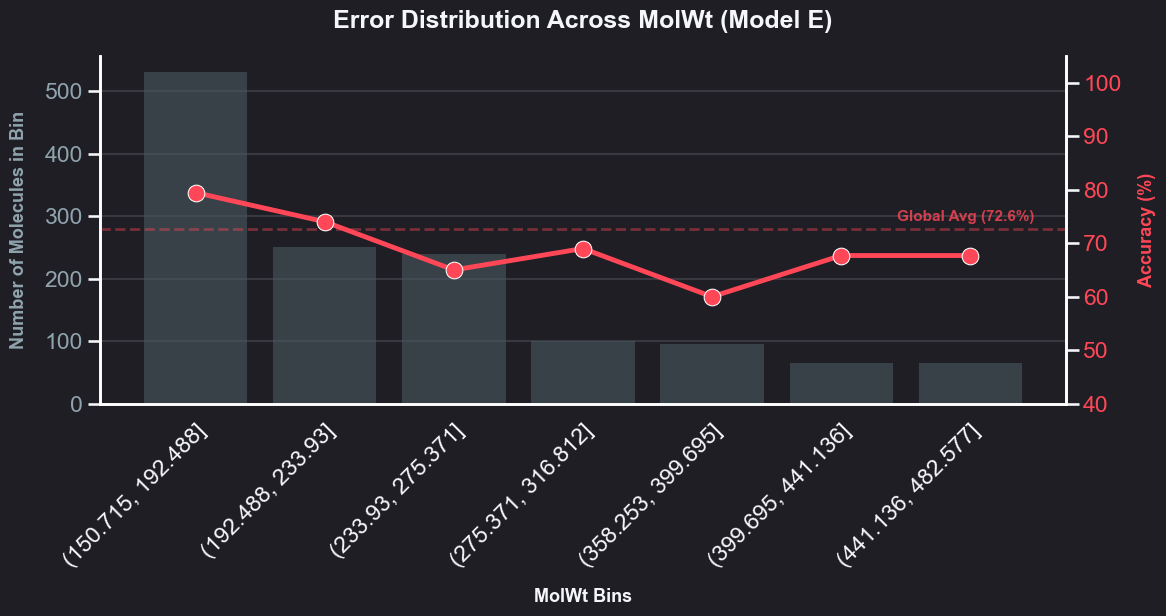

In [208]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='MolWt', num_bins=8) # without weight

In [155]:
def run_bin_analysis_2(X_test, y_true, y_pred, feature_name, feature_names, num_bins=8):

    feature_values = X_test[:, list(feature_names).index(feature_name)]

    results = pd.DataFrame({
        'Feature_Value': feature_values,
        'Actual': y_true,
        'Predicted': y_pred
    })

    results['Bin'] = pd.cut(results['Feature_Value'], bins=num_bins)

    bin_stats = []
    for bin_interval, group in results.groupby('Bin', observed=False):
        if len(group) == 0:
            continue

        acc = accuracy_score(group['Actual'], group['Predicted'])
        errors = len(group) - sum(group['Actual'] == group['Predicted'])

        bin_stats.append({
            'Bin_Range': str(bin_interval),
            'Bin_Center': bin_interval.mid,
            'Total_Molecules': len(group),
            'Errors': errors,
            'Accuracy': acc * 100
        })

    stats_df = pd.DataFrame(bin_stats)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    sns.barplot(data=stats_df, x='Bin_Range', y='Total_Molecules', color='lightgrey', ax=ax1, alpha=0.7)
    ax1.set_ylabel('Number of Molecules in Bin', color='grey', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='grey')
    ax1.set_xlabel(f'{feature_name} Bins', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    ax2 = ax1.twinx()
    sns.lineplot(data=stats_df, x='Bin_Range', y='Accuracy', color='red', marker='o',
                 linewidth=3, markersize=10, ax=ax2)
    ax2.set_ylabel('Accuracy (%)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    global_acc = accuracy_score(y_true, y_pred) * 100
    ax2.axhline(global_acc, color='red', linestyle='--', alpha=0.3, label=f'Global Avg ({global_acc:.1f}%)')
    ax2.set_ylim(min(40, stats_df['Accuracy'].min() - 10), 100)

    plt.title(f'Error Distribution Across {feature_name}', fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()

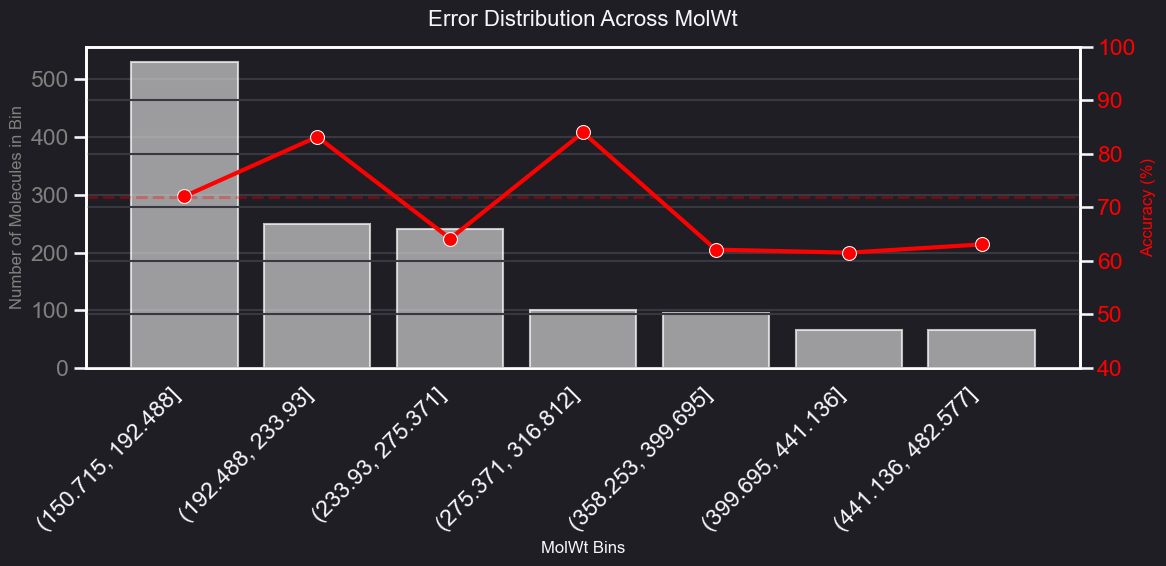

In [227]:
xgb_cols = [col for col in all_cols if col not in cat_cols]  # XGBoost was likely trained without cat cols

run_bin_analysis_2(X_test_E_best, y_test, y_pred_E, feature_name='MolWt', feature_names=xgb_cols)

/var/folders/hp/w678cy2j2fvf_gn9ys7fr_r00000gn/T/ipykernel_24751/3230033712.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')


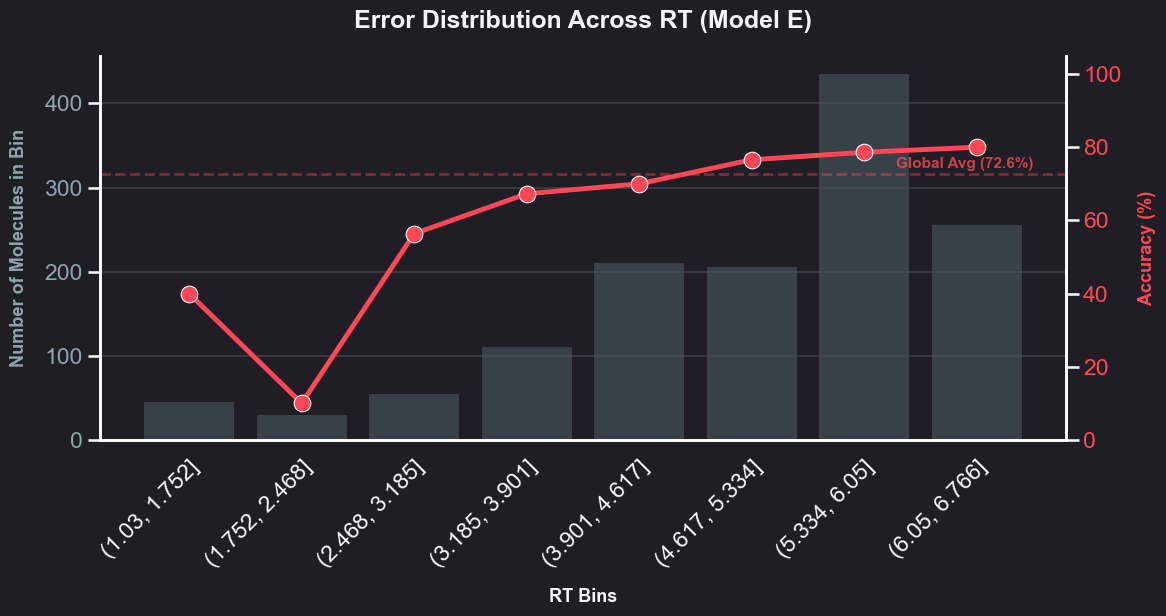

In [223]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='RT', num_bins=8)

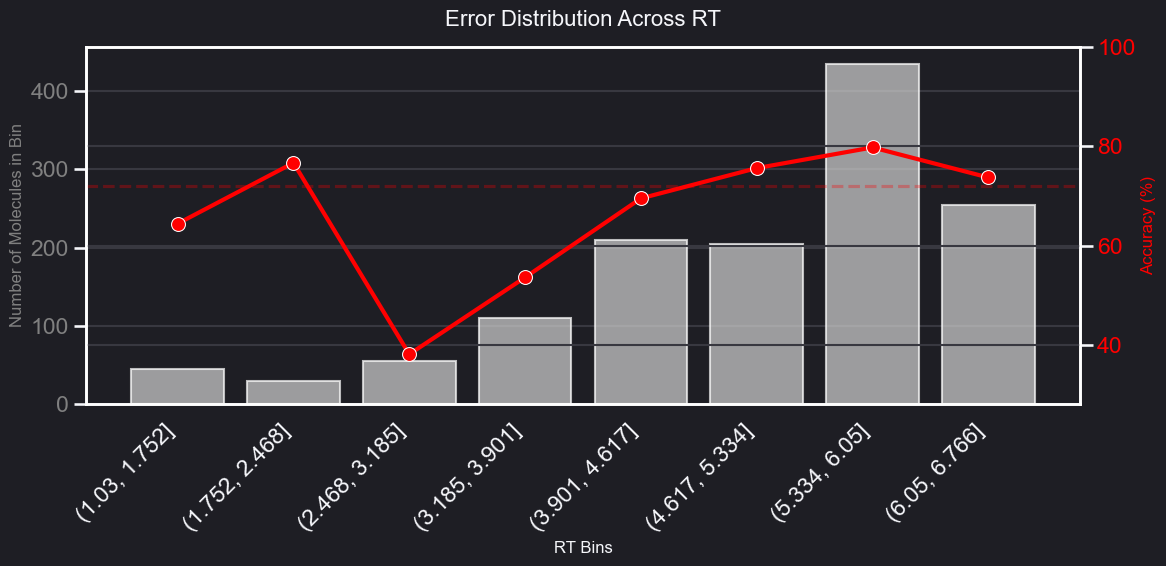

In [228]:
run_bin_analysis_2(X_test_E_best, y_test, y_pred_E, feature_name='RT',    feature_names=xgb_cols)

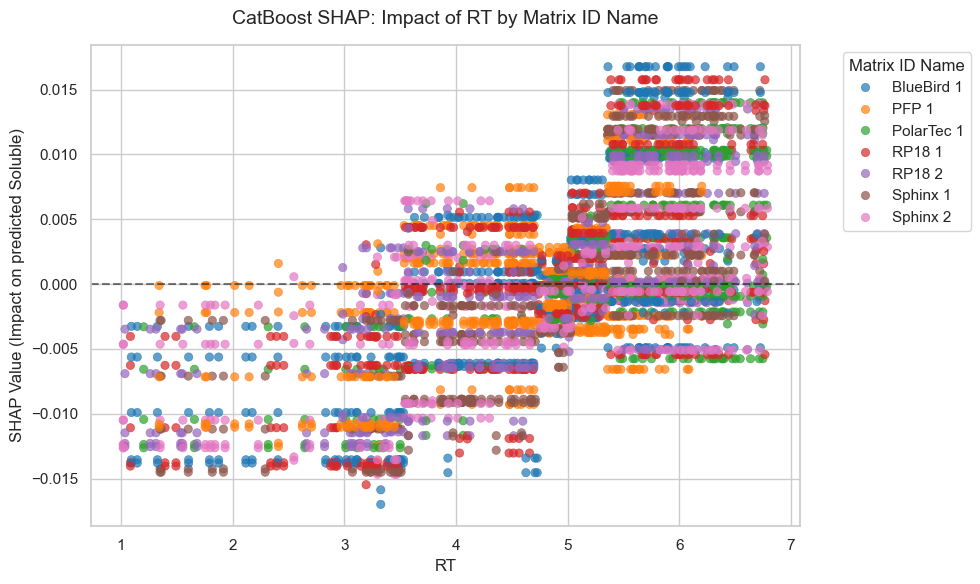

In [266]:
cat_cols = ['Solvent_Name', 'Matrix ID Name']
cont_cols = ['RT', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H'] 
all_cols = cont_cols + vector_cols + cat_cols

plot_catboost_shap_categorical(
    model_cb, 
    df_desc, 
    all_cols, 
    cat_cols, 
    base_feature='RT', 
    color_col='Matrix ID Name'
)

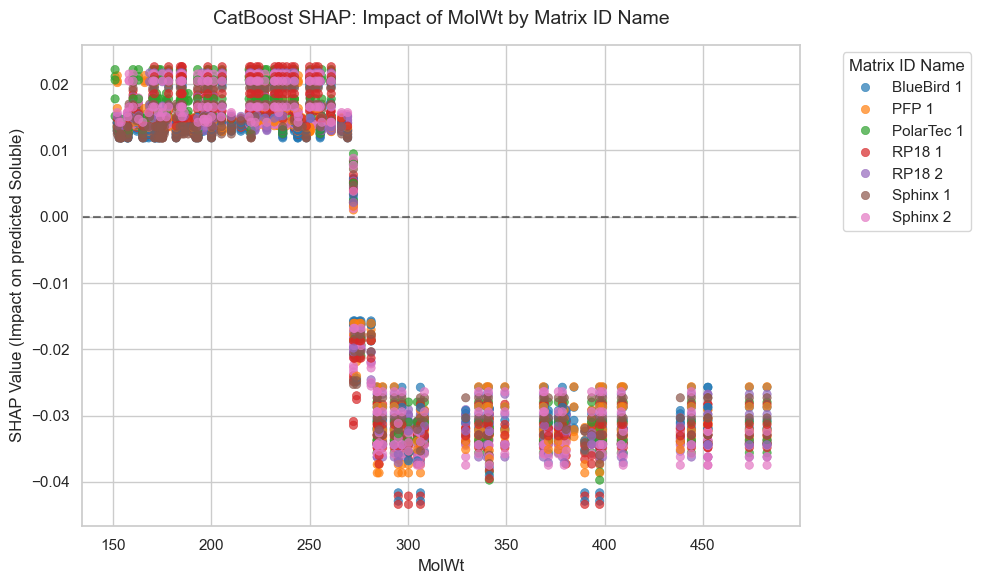

In [267]:
plot_catboost_shap_categorical(
    model_cb, 
    df_desc, 
    all_cols, 
    cat_cols, 
    base_feature='MolWt', 
    color_col='Matrix ID Name'
)

In [271]:
def plot_catboost_learning_curve(df, all_cols, cat_cols, scale_weight, n_splits=5):
    
    X = df[all_cols].copy()
    X[cat_cols] = X[cat_cols].fillna('Missing')
    y = df['Soluble'].values
    groups = df['SMILES'].values  

    train_fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    train_scores = []
    val_scores   = []

    gkf = GroupKFold(n_splits=n_splits)

    for fraction in train_fractions:
        fold_train_scores = []
        fold_val_scores   = []

        for train_idx, val_idx in gkf.split(X, y, groups):

            # --- 2. SLICE THE FRACTION OF TRAINING DATA ---
            n_samples = max(1, int(len(train_idx) * fraction))
            train_idx_fraction = train_idx[:n_samples]

            X_tr_fold = X.iloc[train_idx_fraction]
            y_tr_fold = y[train_idx_fraction]

            X_val_fold = X.iloc[val_idx]
            y_val_fold = y[val_idx]

            # --- 3. TRAIN A FRESH MODEL ON THIS FRACTION ---
            model = CatBoostClassifier(
                iterations=1500,           
                depth=6,                   
                learning_rate=0.01, 
                eval_metric='AUC',         
                random_seed=56,
                l2_leaf_reg=10,             
                min_data_in_leaf=7,
                cat_features=cat_cols,          
                scale_pos_weight=scale_weight,  
                verbose=0                       
            )
            model.fit(X_tr_fold, y_tr_fold)

            # --- 4. SCORE ON BOTH TRAIN AND VAL ---
            fold_train_scores.append(accuracy_score(y_tr_fold, model.predict(X_tr_fold)))
            fold_val_scores.append(accuracy_score(y_val_fold, model.predict(X_val_fold)))

        train_scores.append(np.mean(fold_train_scores))
        val_scores.append(np.mean(fold_val_scores))
        print(f"Fraction {fraction * 100:>3.0f}% done — Train: {np.mean(fold_train_scores):.3f} | Val: {np.mean(fold_val_scores):.3f}")

    
    actual_sizes = [int(len(df) * 0.8 * f) for f in train_fractions]  

    custom_dark_params = {
        "axes.facecolor": "#1e1e24",       
        "figure.facecolor": "#1e1e24",     
        "grid.color": "#383840",           
        "text.color": "#f5f6fa",           
        "axes.labelcolor": "#f5f6fa",
        "xtick.color": "#f5f6fa",
        "ytick.color": "#f5f6fa"
    }
    sns.set_theme(style="darkgrid", context="talk", rc=custom_dark_params)

    fig, ax = plt.subplots(figsize=(11, 6.5))
    
    # Training Curve (Blue)
    ax.plot(actual_sizes, train_scores, 'o-', color='#3498db', linewidth=3, markersize=9, label='Training Accuracy')
    
    # Validation Curve (Red/Coral)
    ax.plot(actual_sizes, val_scores, 'o-', color='#ff4757', linewidth=3, markersize=9, label='Validation Accuracy')
    
    # Shaded Area between curves
    ax.fill_between(actual_sizes, train_scores, val_scores, alpha=0.15, color='#95a5a6', edgecolor='none')
    
    # 50% Baseline 
    ax.axhline(y=0.5, color='#f5f6fa', linestyle='--', linewidth=1.5, alpha=0.3, zorder=0)
    
    # Typography
    ax.set_title('CatBoost Learning Curve', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Number of Training Samples', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold', labelpad=12)
    
    # Clean axes limits
    ax.set_ylim([0.4, 1.05])
    ax.set_xlim(left=0)
    
    # Floating legend
    legend = ax.legend(loc='lower right', frameon=False, fontsize=12)
    
    # Remove top/right box lines
    sns.despine(ax=ax, top=True, right=True)
    
    plt.tight_layout()
    plt.show()

    return train_scores, val_scores

Fraction  10% done — Train: 0.909 | Val: 0.568
Fraction  20% done — Train: 0.939 | Val: 0.549
Fraction  30% done — Train: 0.921 | Val: 0.564
Fraction  40% done — Train: 0.923 | Val: 0.553
Fraction  50% done — Train: 0.910 | Val: 0.598
Fraction  60% done — Train: 0.928 | Val: 0.592
Fraction  70% done — Train: 0.904 | Val: 0.632
Fraction  80% done — Train: 0.905 | Val: 0.636
Fraction  90% done — Train: 0.899 | Val: 0.648
Fraction 100% done — Train: 0.908 | Val: 0.645


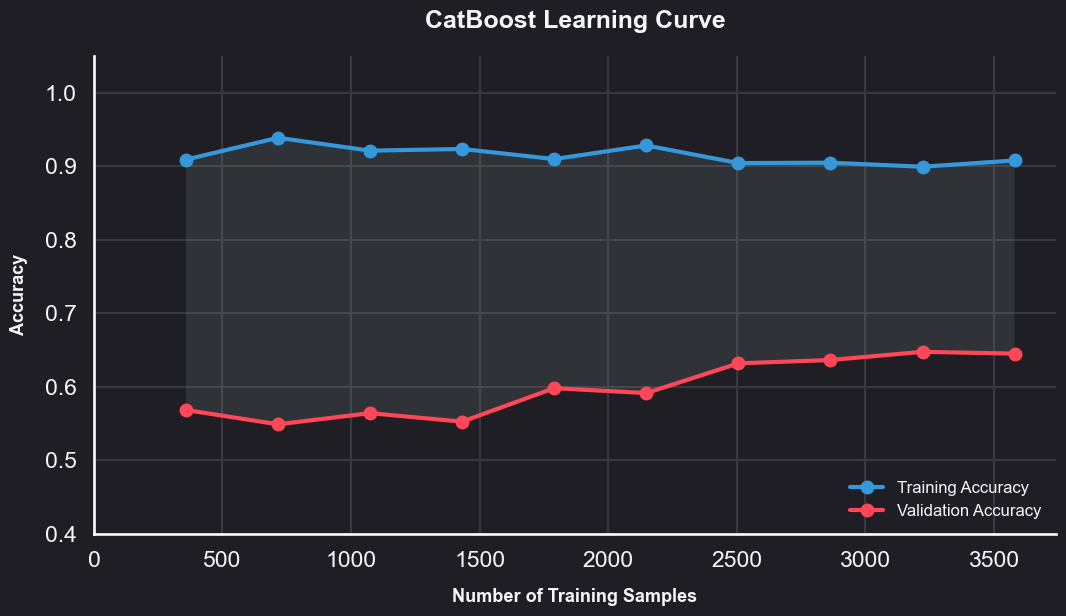

In [272]:
cat_cols  = ['Solvent_Name', 'Matrix ID Name']
cont_cols = ['RT', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
vector_cols = matrix_vectors_df.columns.tolist()
all_cols  = cont_cols + vector_cols + cat_cols

train_scores, val_scores = plot_catboost_learning_curve(
    df_desc, all_cols, cat_cols, scale_weight
)

In [62]:
# Get probabilities for the full test set
X_test_pool = catboost.Pool(data=X_test_cb, cat_features=cat_cols)
test_probas = model_cb.predict_proba(X_test_pool)[:, 1]

# Build results dataframe
results_df = pd.DataFrame({
    'SMILES':    df_desc.iloc[test_idx]['SMILES'].values,
    'Solvent':   df_desc.iloc[test_idx]['Solvent_Name'].values,
    'Actual':    y_test_cb.values,
    'Confidence': test_probas
})


correct        = 0
wrong_but_safe = 0
critical_fail  = 0
total          = 0

for smiles, group in results_df.groupby('SMILES'):
    # Skip molecules with only one solvent or no variation in actual labels
    if group['Actual'].nunique() < 2:
        continue
    
    total += 1
    
    # --- AGGREGATE ACROSS MACHINES ---
    group_agg = group.groupby('Solvent').agg(
        Confidence=('Confidence', 'mean'),
        Actual=('Actual', 'max')
    ).reset_index()
    
    ranked = group_agg.sort_values('Confidence', ascending=False)
    
    top_is_soluble = ranked.iloc[0]['Actual'] == 1
    
    soluble_confidences   = group_agg[group_agg['Actual'] == 1]['Confidence']
    insoluble_confidences = group_agg[group_agg['Actual'] == 0]['Confidence']
    
    order_correct = soluble_confidences.min() > insoluble_confidences.max()
    
    if order_correct:
        correct += 1
    elif top_is_soluble:
        wrong_but_safe += 1
    else:
        critical_fail += 1

    print(f"\n{'='*55}")
    print(f"Molecule: {smiles}")
    print(f"{'─'*55}")
    print(f"  {'Rank':<6} {'Solvent':<12} {'Confidence':>12} {'Actual':>10}")
    print(f"{'─'*55}")
    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        actual_label = '✓ soluble' if row['Actual'] == 1 else '✗ insoluble'
        marker = '▶' if rank == 1 else ' '
        print(f"  {marker}{rank:<5} {row['Solvent']:<12} {row['Confidence']*100:>10.1f}%  {actual_label:>10}")

print(f"\n{'='*55}")
print(f"SUMMARY")
print(f"{'='*55}")

print(f"Total molecules evaluated:       {total}")
print(f"")
print(f"Order fully correct:             {correct}  ({100*correct/total:.1f}%)")
print(f"Wrong order but top pick safe:   {wrong_but_safe}  ({100*wrong_but_safe/total:.1f}%)")
print(f"Critical failure (top insoluble):{critical_fail}  ({100*critical_fail/total:.1f}%)")


Molecule: C(/C(=C\C(=O)O)/C(=O)O)C(=O)O
───────────────────────────────────────────────────────
  Rank   Solvent        Confidence     Actual
───────────────────────────────────────────────────────
  ▶1     DMSO               86.4%   ✓ soluble
   2     MeOH               75.4%   ✓ soluble
   3     ACN                68.2%   ✓ soluble
   4     CHCl3              64.6%  ✗ insoluble
   5     DCM                63.9%  ✗ insoluble

Molecule: C1=CC(=CC=C1C2=CC=C(C=C2)O)O
───────────────────────────────────────────────────────
  Rank   Solvent        Confidence     Actual
───────────────────────────────────────────────────────
  ▶1     DMSO               84.0%   ✓ soluble
   2     CHCl3              74.6%  ✗ insoluble
   3     DCM                74.3%  ✗ insoluble
   4     ACN                73.6%  ✗ insoluble
   5     MeOH               73.4%  ✗ insoluble

Molecule: C1=CC2=C(C=CN2)C=C1C(F)(F)F
───────────────────────────────────────────────────────
  Rank   Solvent        Confidence     Act

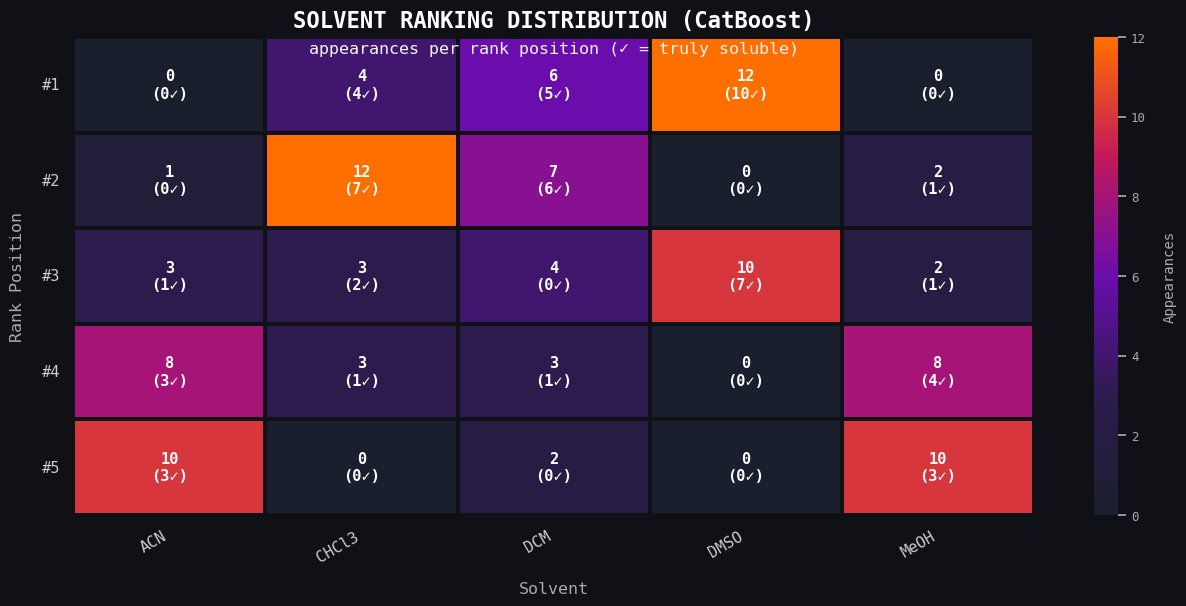

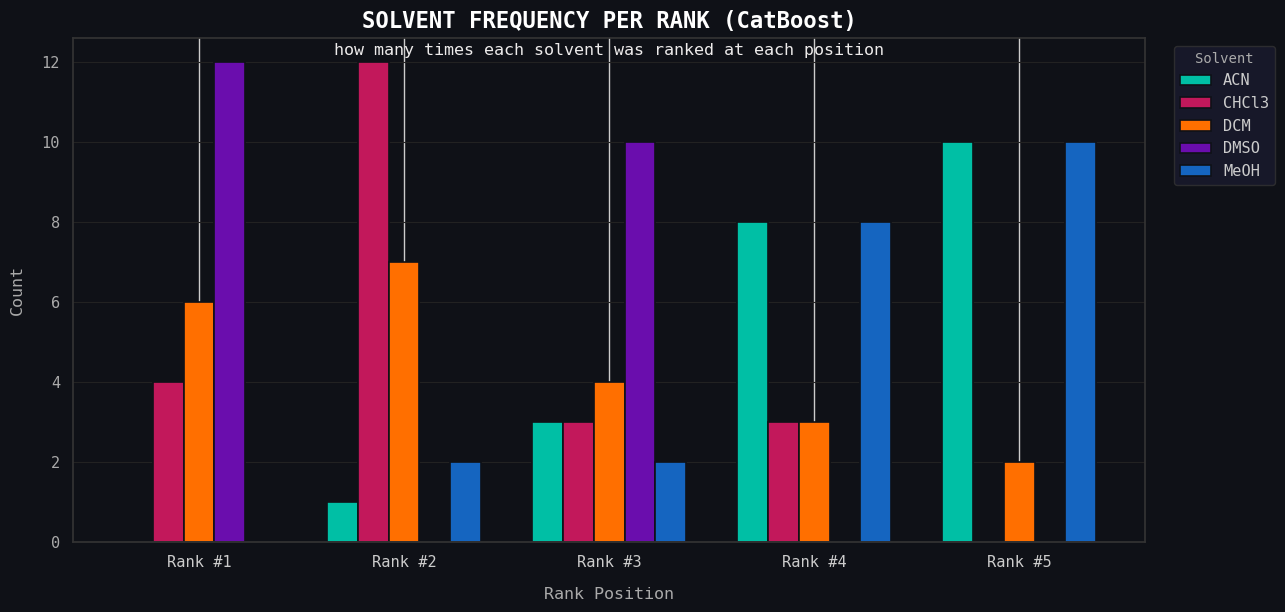

In [189]:
rank_records = []

for smiles, group in results_df.groupby('SMILES'):
    if group['Actual'].nunique() < 2:
        continue

    group_agg = group.groupby('Solvent').agg(
        Confidence=('Confidence', 'mean'),
        Actual=('Actual', 'max')
    ).reset_index()

    ranked = group_agg.sort_values('Confidence', ascending=False).reset_index(drop=True)

    for rank, (_, row) in enumerate(ranked.iterrows(), 1):
        rank_records.append({
            'Solvent': row['Solvent'],
            'Rank': rank,
            'Correct': int(row['Actual'] == 1)
        })

rank_df = pd.DataFrame(rank_records)

# ranking count
count_matrix = rank_df.groupby(['Rank', 'Solvent']).size().unstack(fill_value=0)
correct_matrix = rank_df.groupby(['Rank', 'Solvent'])['Correct'].sum().unstack(fill_value=0)

annot_matrix = count_matrix.copy().astype(object)
for rank in count_matrix.index:
    for solvent in count_matrix.columns:
        total   = count_matrix.loc[rank, solvent]
        correct = correct_matrix.loc[rank, solvent]
        annot_matrix.loc[rank, solvent] = f"{total}\n({correct}✓)"


# Heatmap parameters
plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

dark_cmap = LinearSegmentedColormap.from_list(
    'dark_chem', ['#1a1f2e', '#2d1b4e', '#6a0dad', '#c2185b', '#ff6f00'], N=256
)

sns.heatmap(
    count_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=dark_cmap,
    linewidths=1.5,
    linecolor='#0f1117',
    ax=ax,
    cbar=True,
    annot_kws={'size': 11, 'color': 'white', 'fontfamily': 'monospace', 'fontweight': 'bold'}
)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
cbar.outline.set_edgecolor('#333333')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa', fontsize=9)
cbar.set_label('Appearances', color='#aaaaaa', fontsize=10, labelpad=12)

ax.tick_params(colors='#cccccc', labelsize=11)
ax.set_xlabel('Solvent', color='#aaaaaa', fontsize=12, labelpad=12)
ax.set_ylabel('Rank Position', color='#aaaaaa', fontsize=12, labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_yticklabels(
    [f'#{i}' for i in count_matrix.index],
    rotation=0, color='#cccccc', fontsize=11
)
ax.set_xticklabels(
    count_matrix.columns,
    rotation=30, ha='right', color='#cccccc', fontsize=11
)

fig.text(0.5, 1.01, 'SOLVENT RANKING DISTRIBUTION (CatBoost)',
         ha='center', va='bottom', fontsize=16,
         color='white', fontfamily='monospace', fontweight='bold', transform=ax.transAxes)
fig.text(0.5, 0.96, 'appearances per rank position (✓ = truly soluble)',
         ha='center', va='bottom', fontsize=12,
         color="#F6F6F6", fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# ── BAR CHART ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 6))
fig2.patch.set_facecolor('#0f1117')
ax2.set_facecolor('#0f1117')

bar_colors = ['#00bfa5', '#c2185b', '#ff6f00', '#6a0dad', '#1565c0']
x = np.arange(len(count_matrix.index))
width = 0.15

for i, solvent in enumerate(count_matrix.columns):
    ax2.bar(
        x + i * width,
        count_matrix[solvent].values,
        width=width,
        label=solvent,
        color=bar_colors[i % len(bar_colors)],
        edgecolor='#0f1117',
        linewidth=1.2
    )

ax2.set_facecolor('#0f1117')
ax2.tick_params(colors='#cccccc', labelsize=11)
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels([f'Rank #{i}' for i in count_matrix.index],
                     color='#cccccc', fontsize=11)
ax2.set_xlabel('Rank Position', color='#aaaaaa', fontsize=12, labelpad=12)
ax2.set_ylabel('Count', color='#aaaaaa', fontsize=12, labelpad=12)

for spine in ax2.spines.values():
    spine.set_edgecolor('#333333')

ax2.yaxis.set_tick_params(labelcolor='#aaaaaa')
ax2.grid(axis='y', color='#222222', linewidth=0.8)

legend = ax2.legend(
    title='Solvent', title_fontsize=10,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    facecolor='#1a1a2e', edgecolor='#333333',
    labelcolor='#cccccc'
)
legend.get_title().set_color('#aaaaaa')

fig2.text(0.5, 1.01, 'SOLVENT FREQUENCY PER RANK (CatBoost)',
          ha='center', va='bottom', fontsize=16,
          color='white', fontfamily='monospace', fontweight='bold', transform=ax2.transAxes)
fig2.text(0.5, 0.96, 'how many times each solvent was ranked at each position',
          ha='center', va='bottom', fontsize=12,
          color="#EDEBEB", fontfamily='monospace', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

In [241]:
def plot_catboost_solvent_gallery(model, X_test_df, base_feature='MolWt', color_col='Matrix ID Name'):
    """
    Generates a separate SHAP plot for every unique solvent in the CatBoost test set.
    """

    
    # 1. Initialize Explainer directly on the DataFrame
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer.shap_values(X_test_df)
    
    # 2. Get the exact column index automatically
    feature_idx = X_test_df.columns.get_loc(base_feature)
    
    # 3. Identify unique solvents natively
    solvents = X_test_df['Solvent_Name'].unique()
    


    for sol in solvents:
        # 4. Filter for THIS solvent
        sol_mask = X_test_df['Solvent_Name'] == sol
        
        # Pull out the specific SHAP values and raw values
        sol_shap = shap_values_all[sol_mask, feature_idx]
        sol_raw_val = X_test_df.loc[sol_mask, base_feature]
        sol_color = X_test_df.loc[sol_mask, color_col]
        
        # 5. Create the Plot
        plt.figure(figsize=(15, 11))
        
        sns.scatterplot(
            x=sol_raw_val, 
            y=sol_shap, 
            hue=sol_color, 
            palette='viridis', 
            alpha=0.8,
            edgecolor='w',
            linewidth=0.5
        )
        
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        plt.title(f"SHAP Impact of {base_feature} in {sol} (Catboost)", fontsize=14)
        plt.xlabel(f"Raw {base_feature}")
        plt.ylabel("SHAP Value (Impact on Solubility)")
        
        # Move legend outside the plot so it doesn't cover data
        plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.2)
        
        plt.tight_layout()
        plt.show()

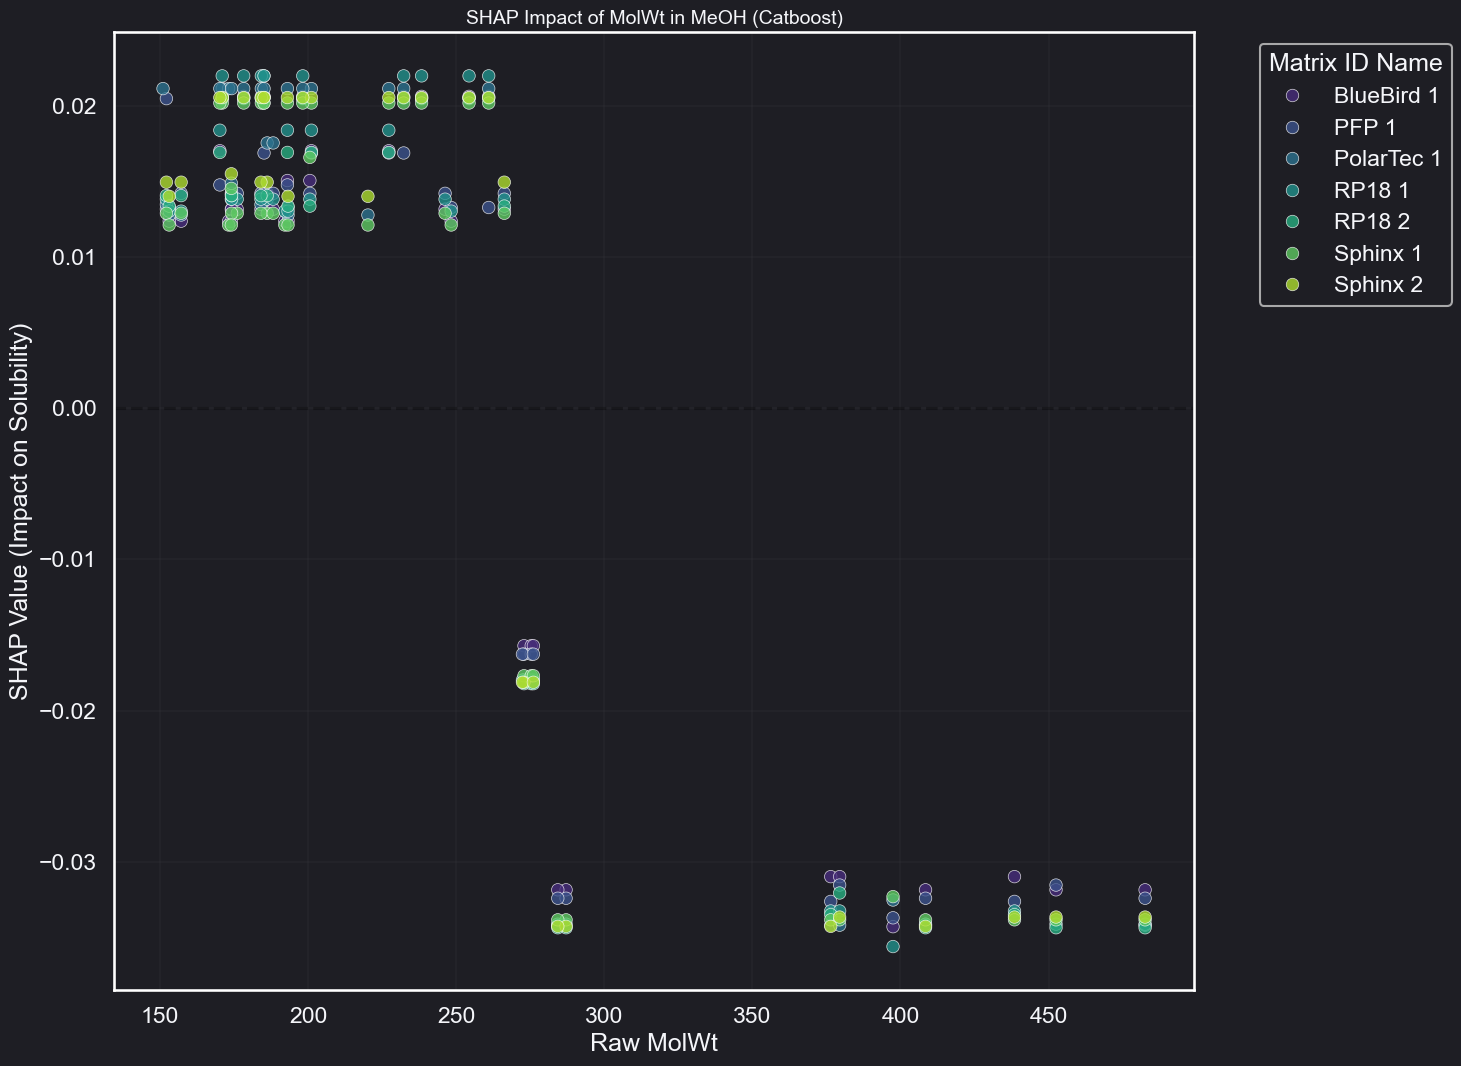

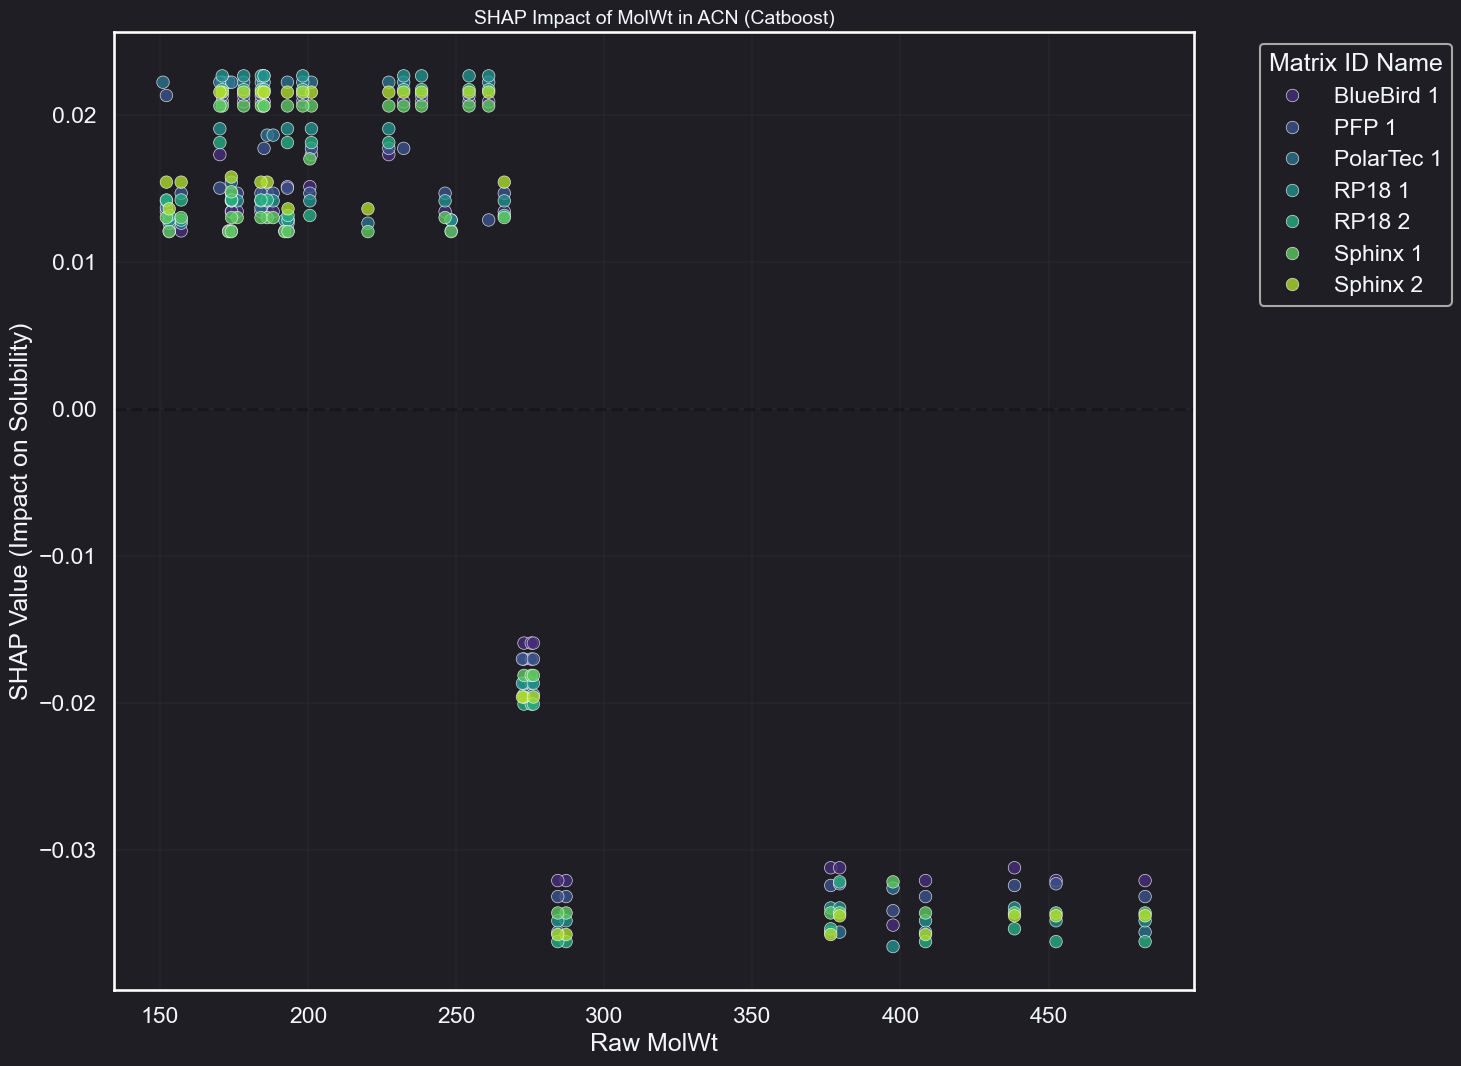

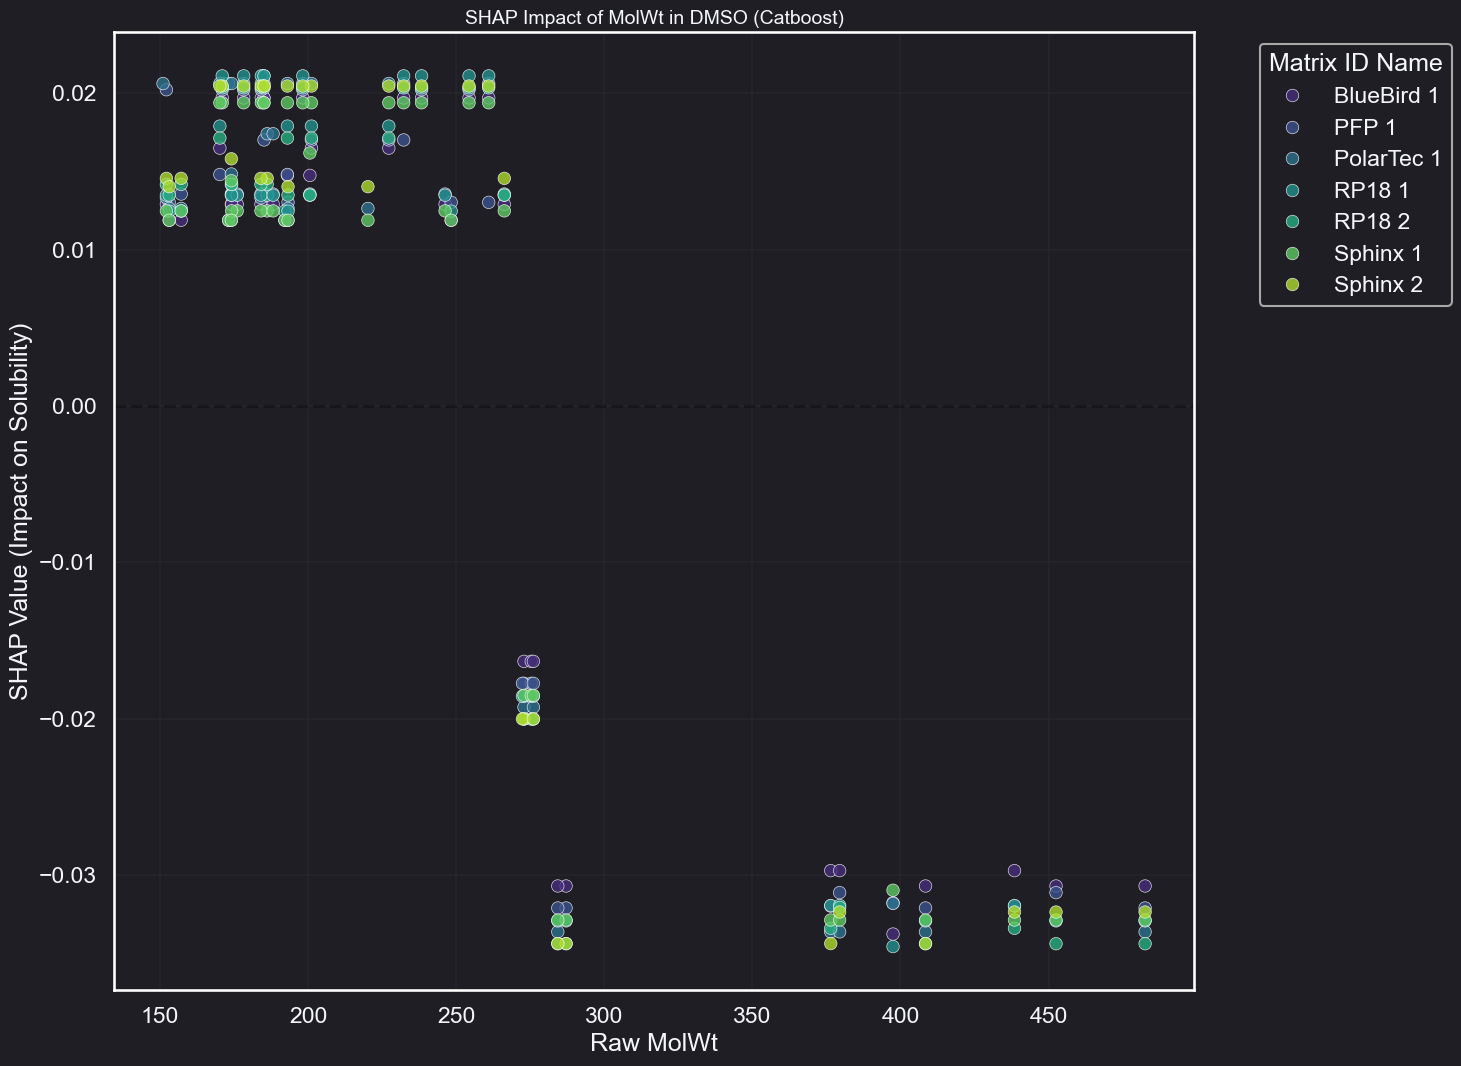

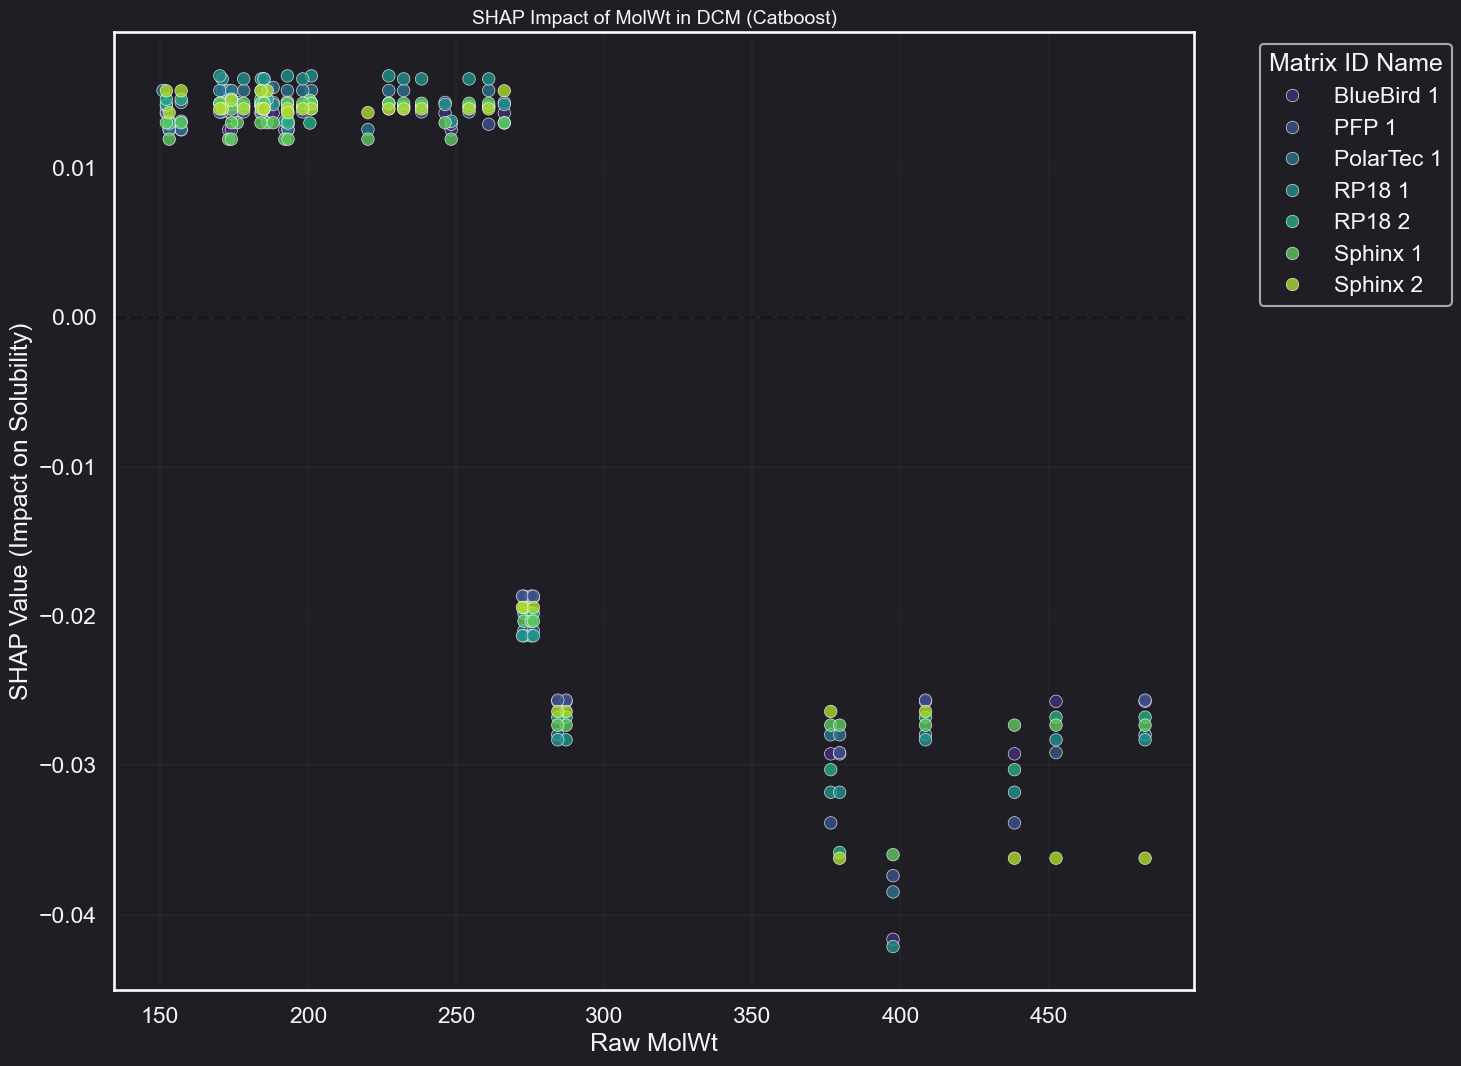

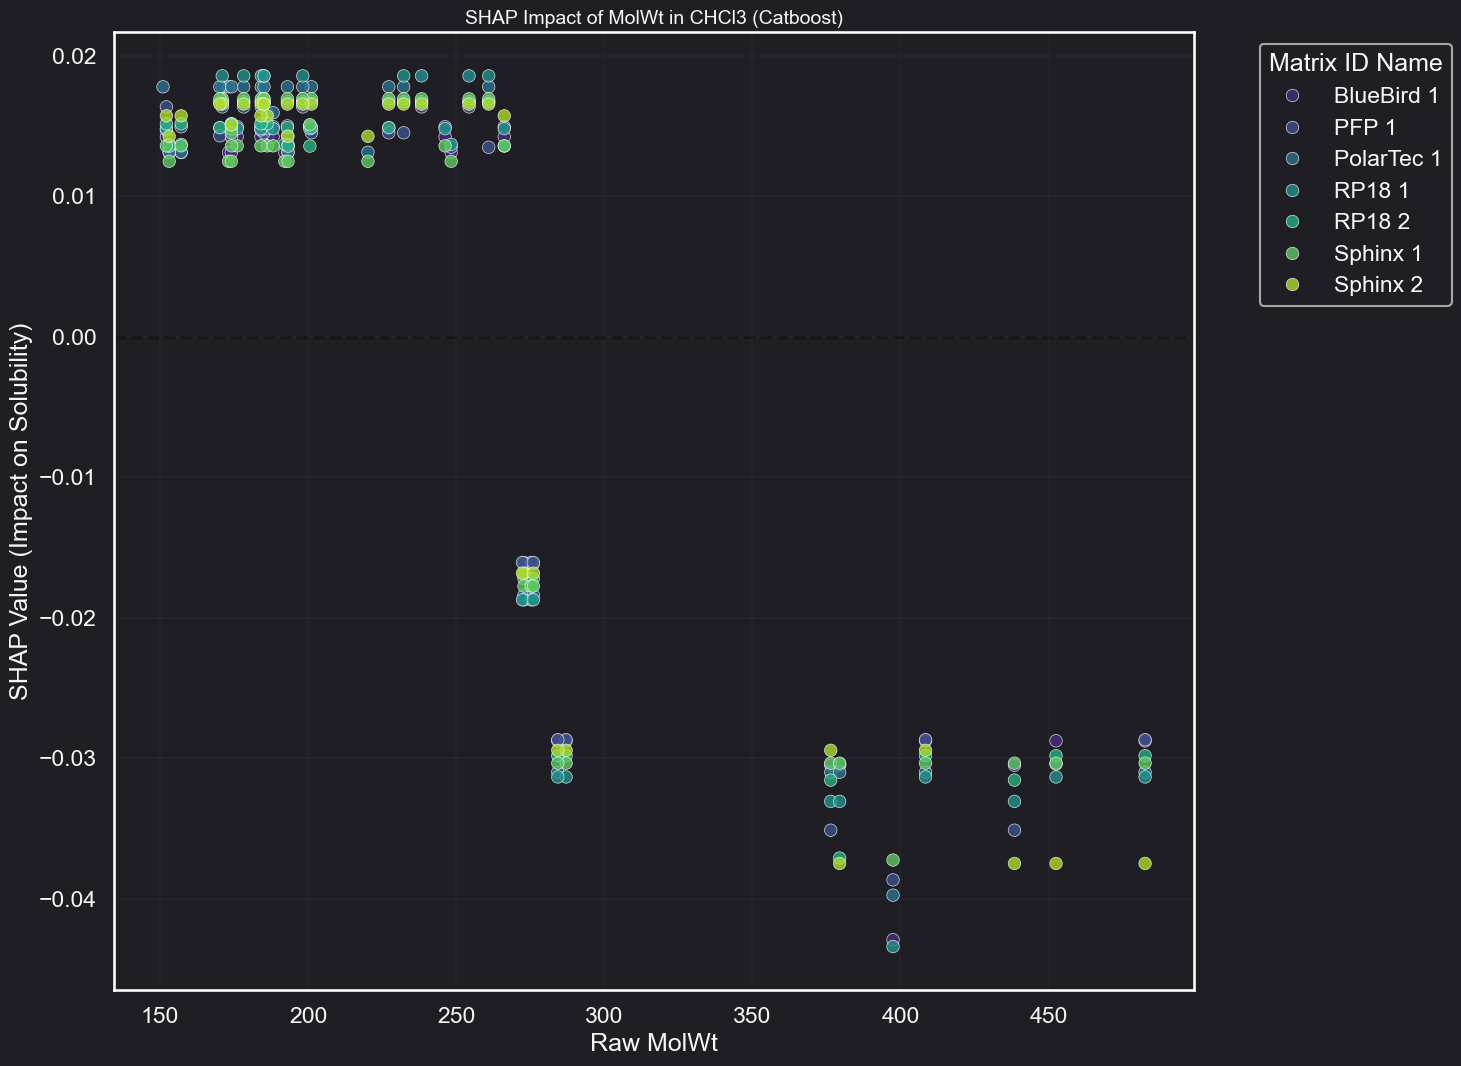

In [273]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='MolWt',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Matrix ID Name' 
)

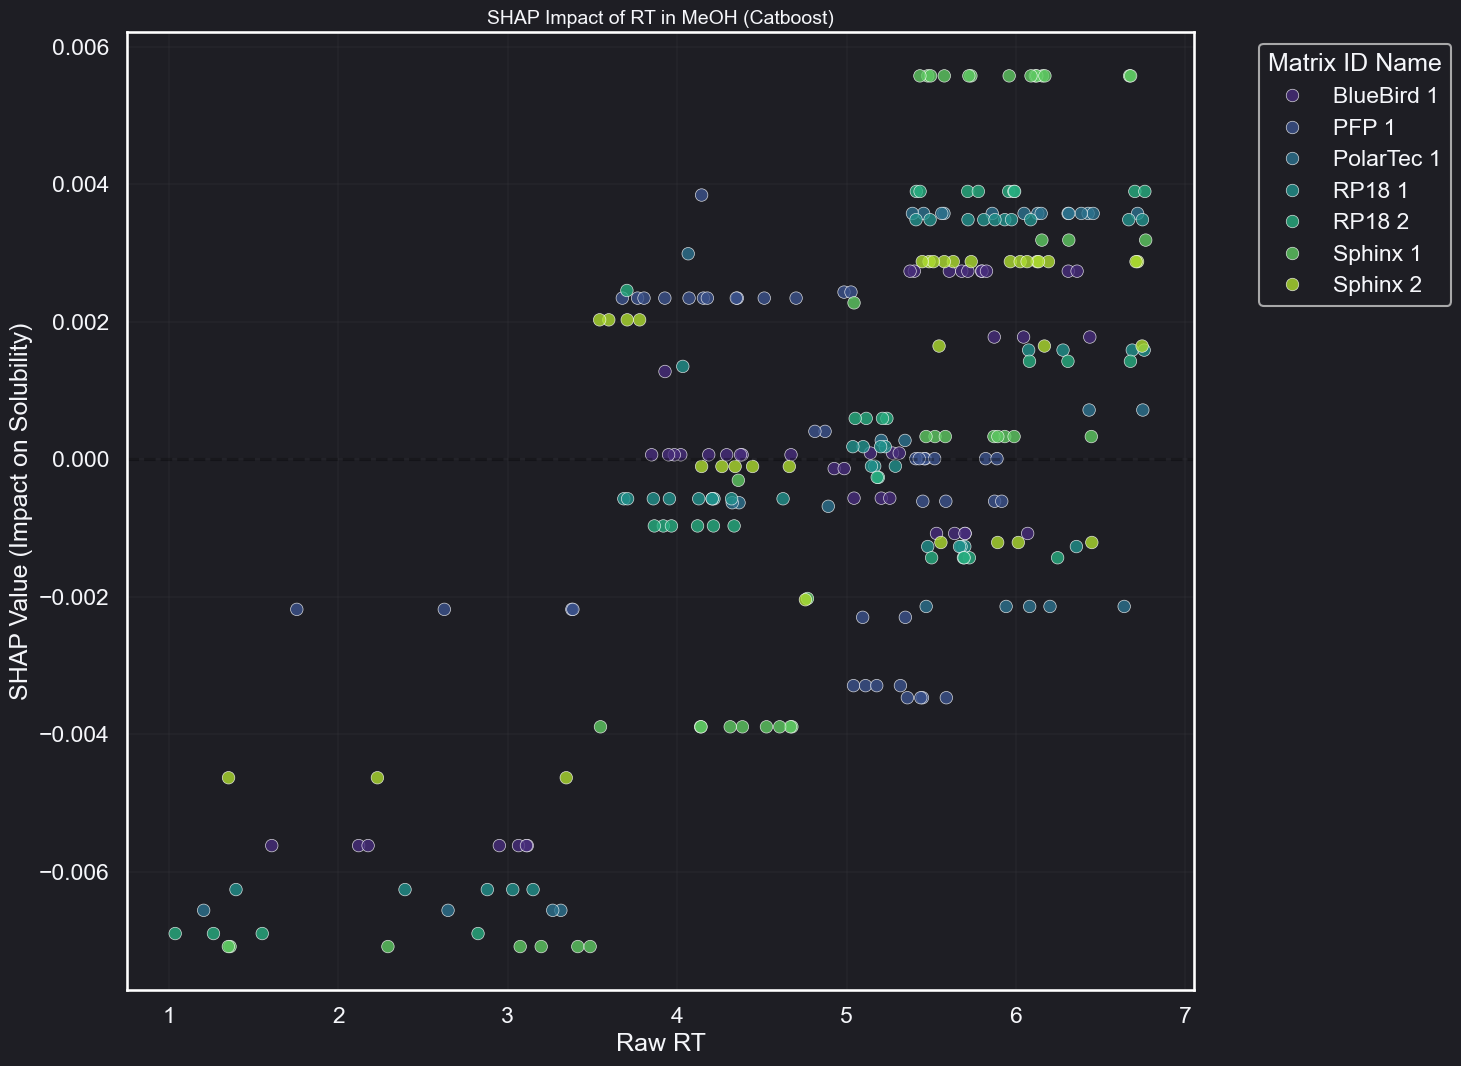

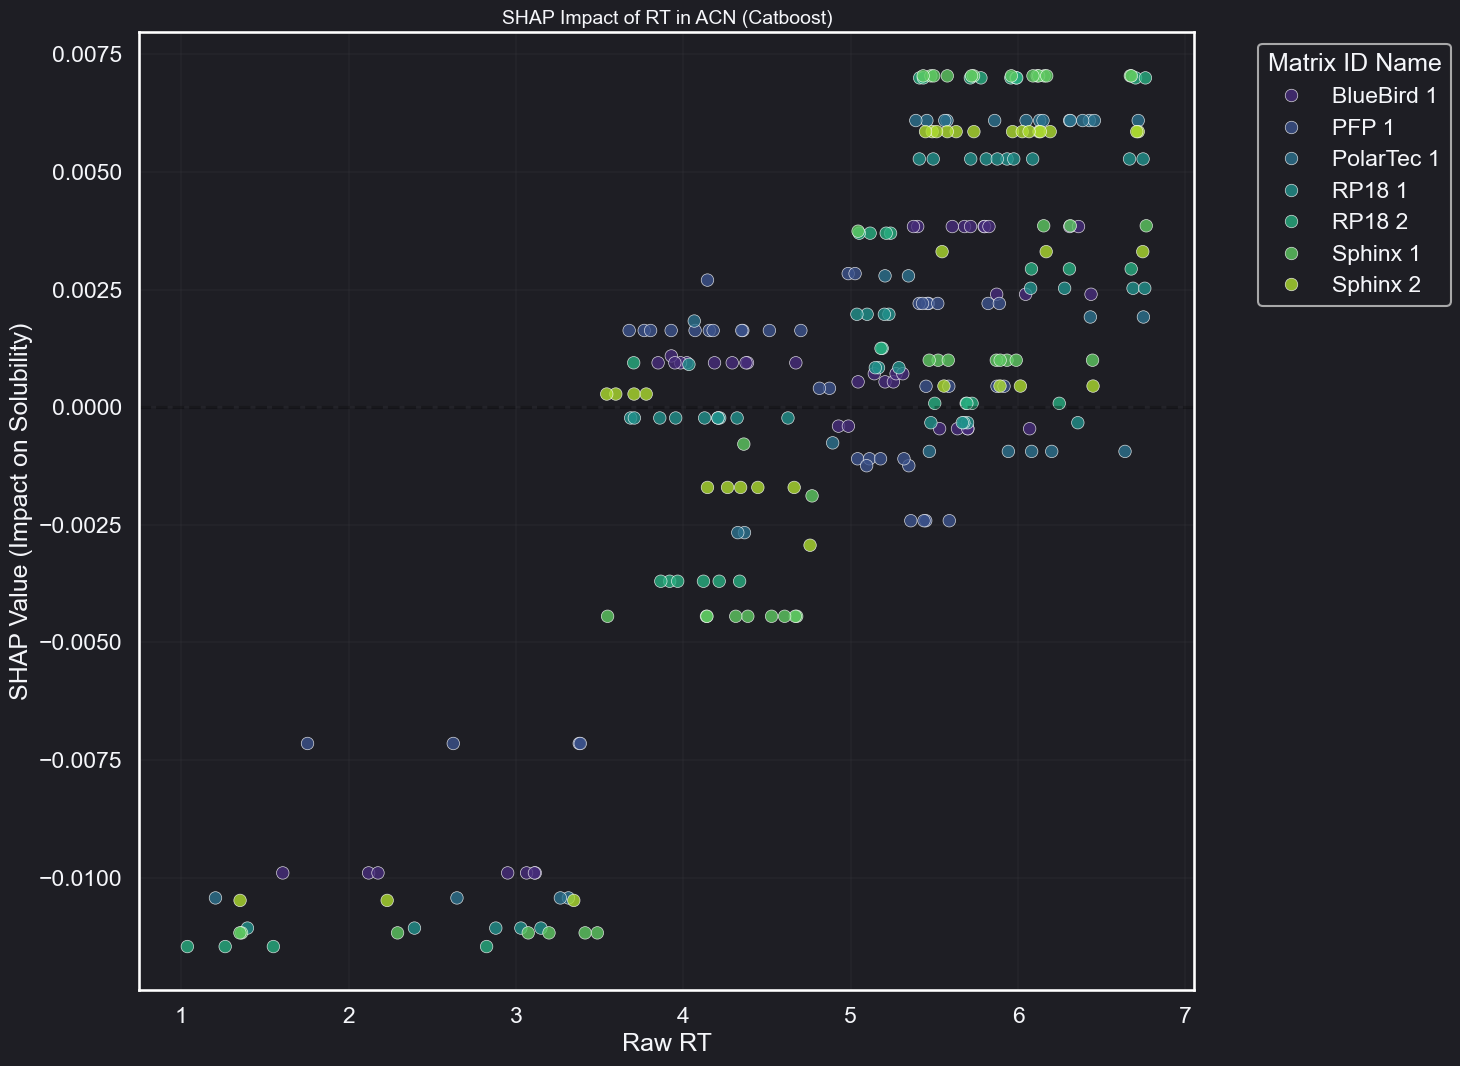

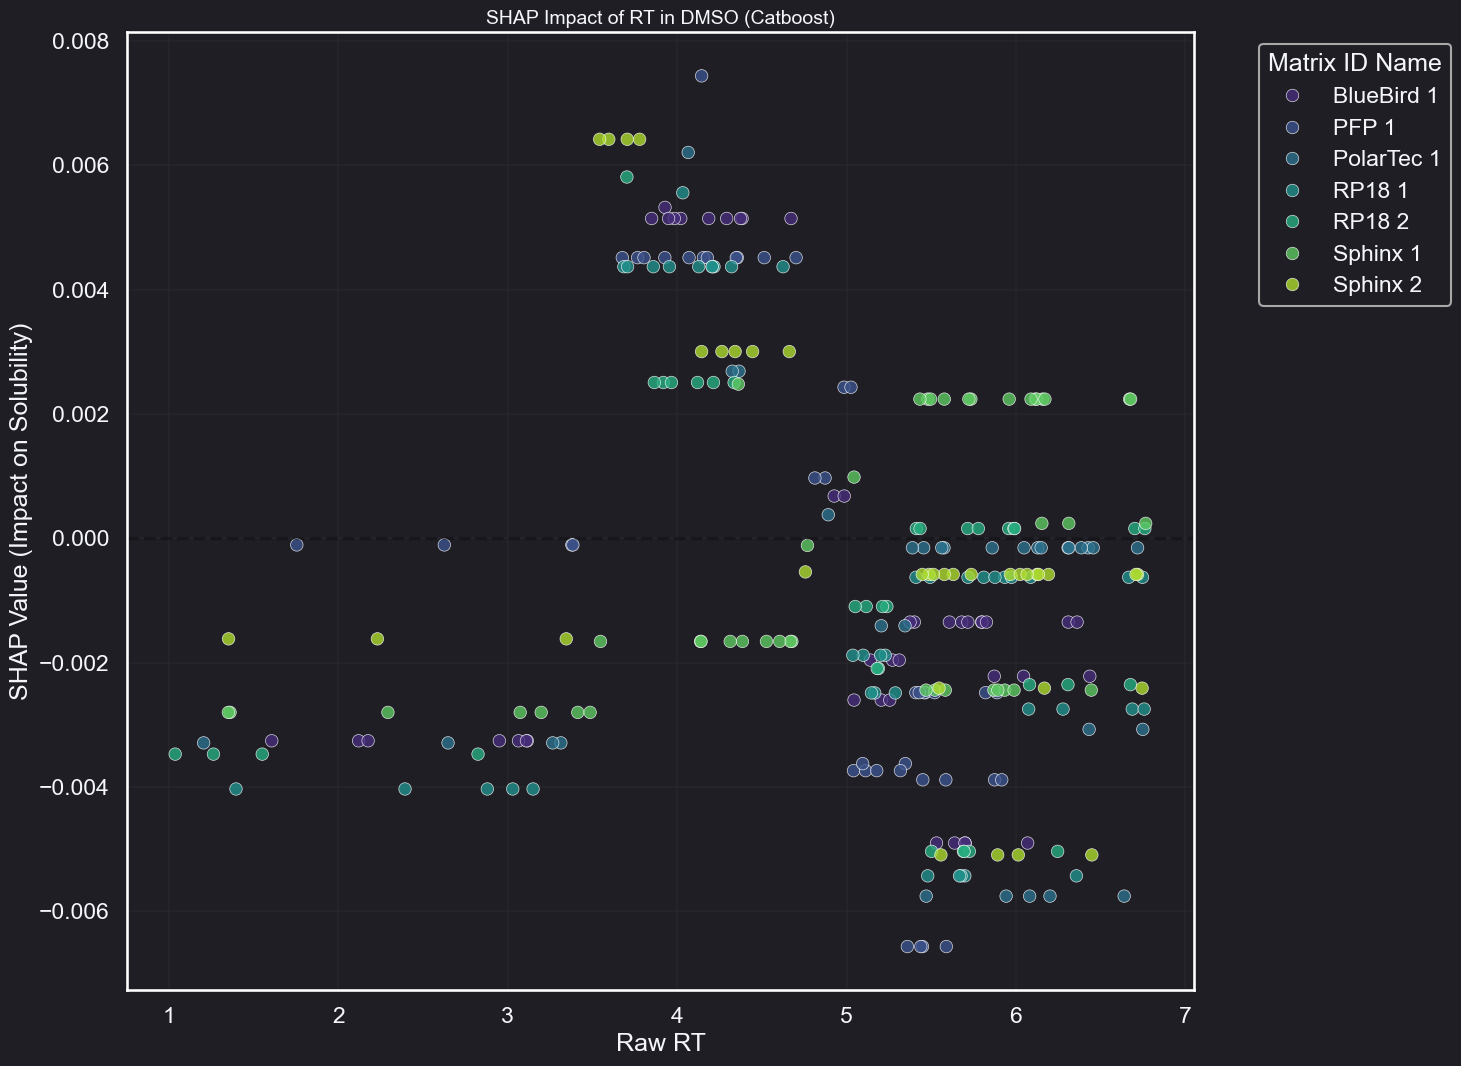

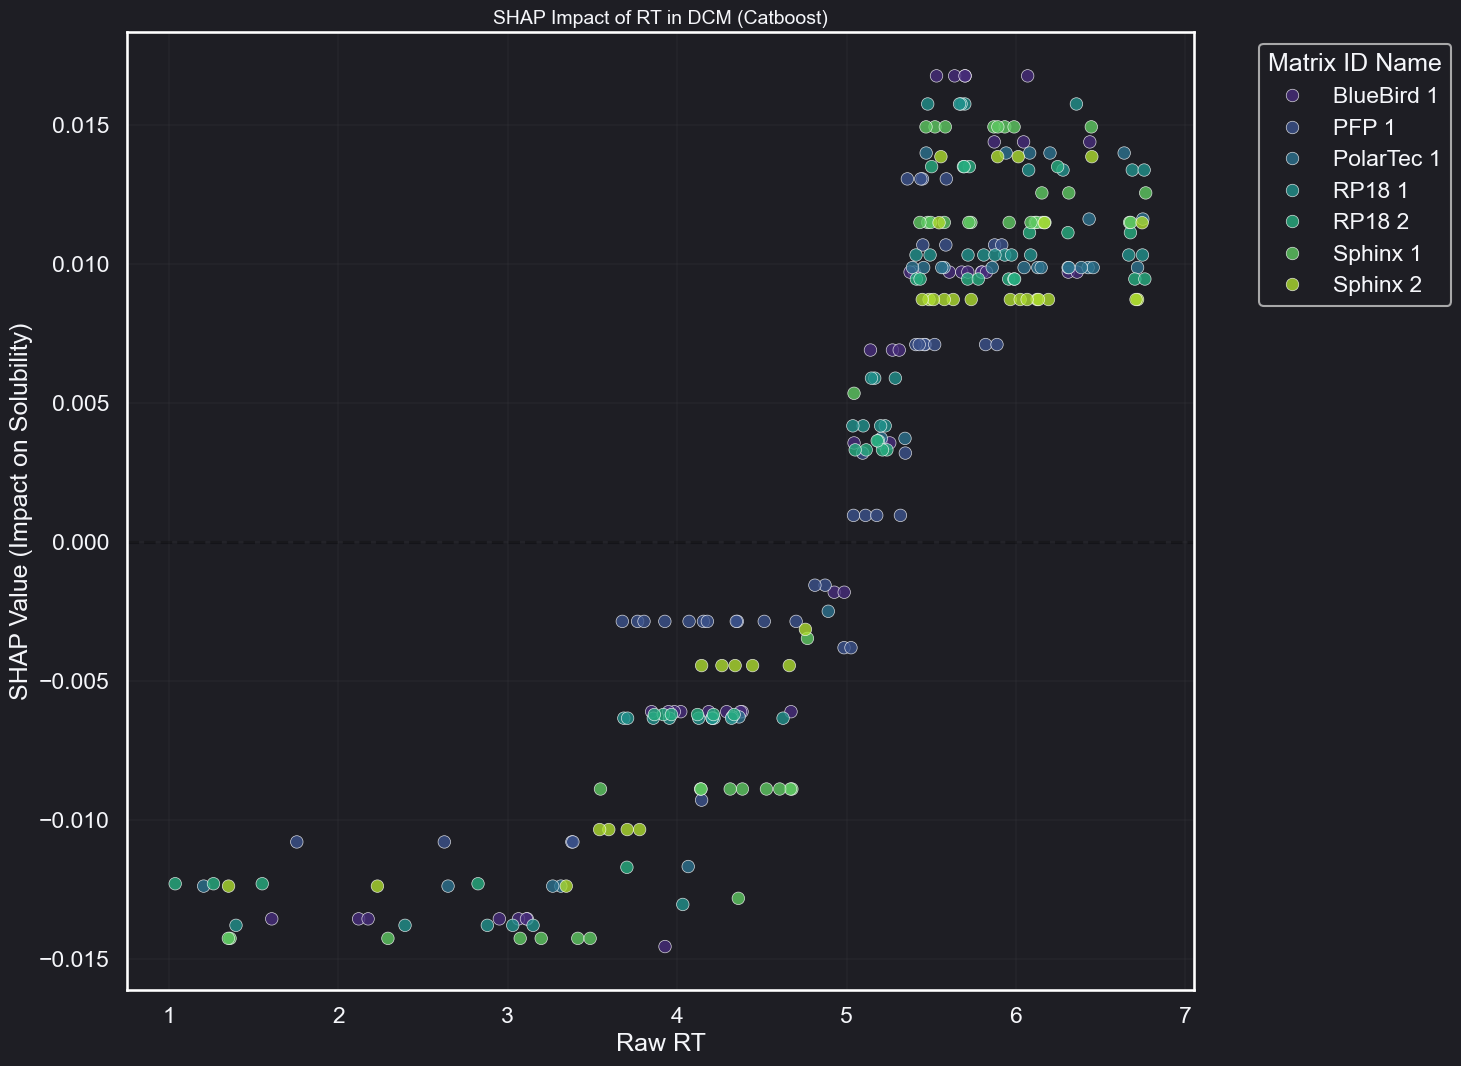

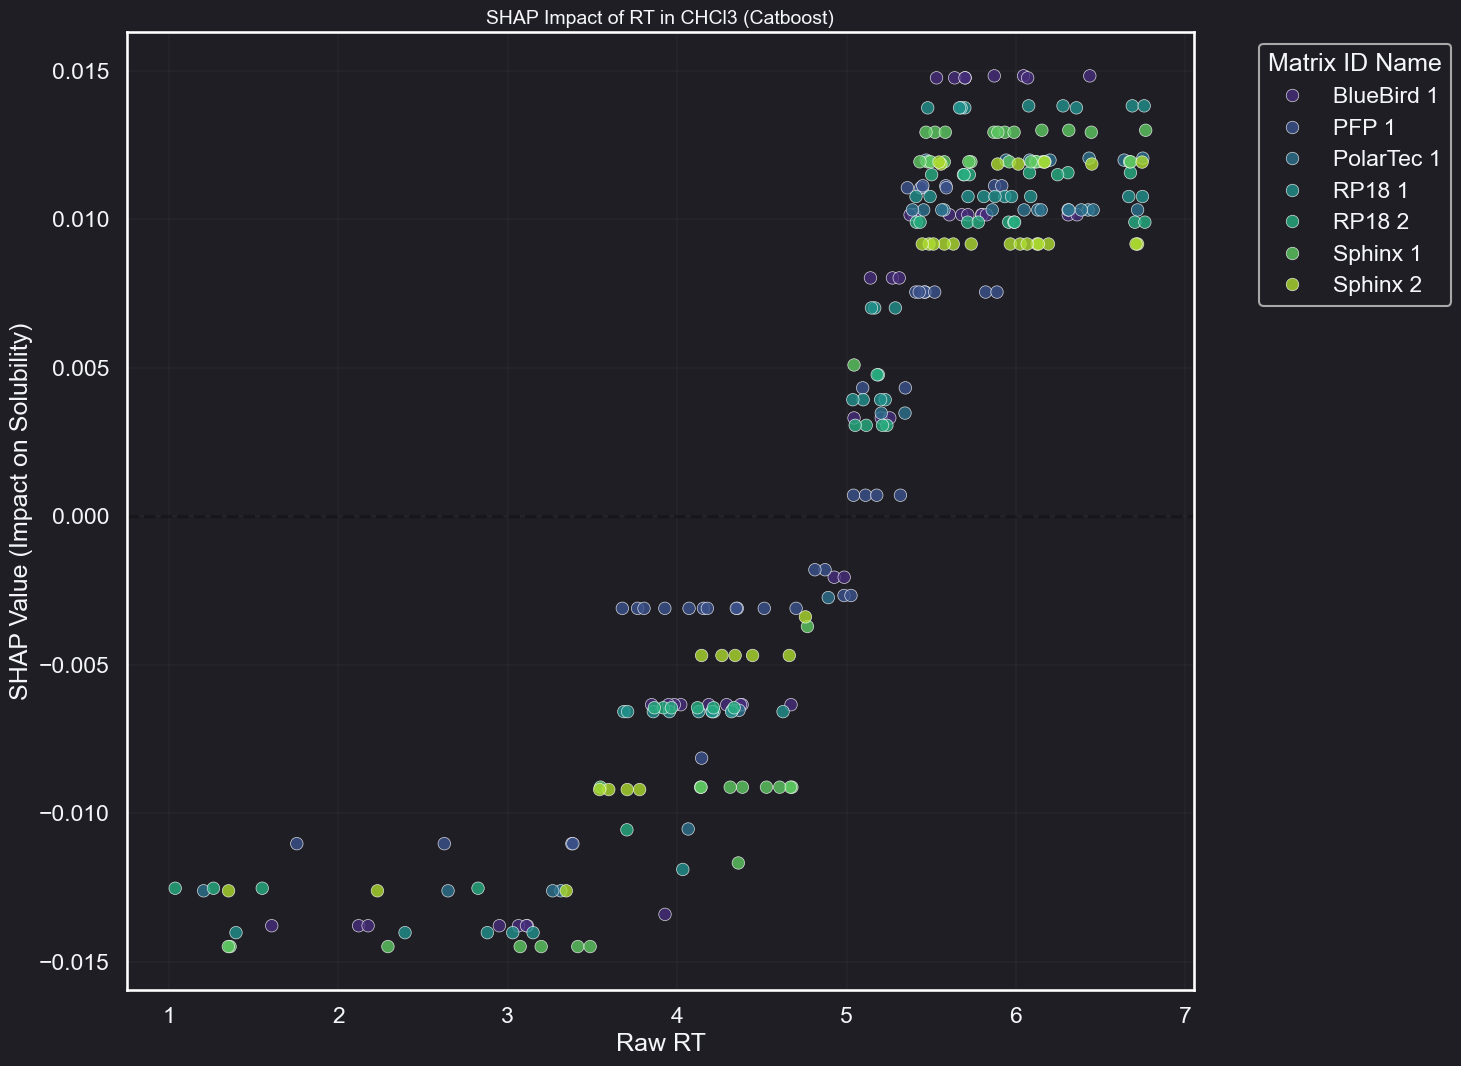

In [274]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='RT',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Matrix ID Name' 
)

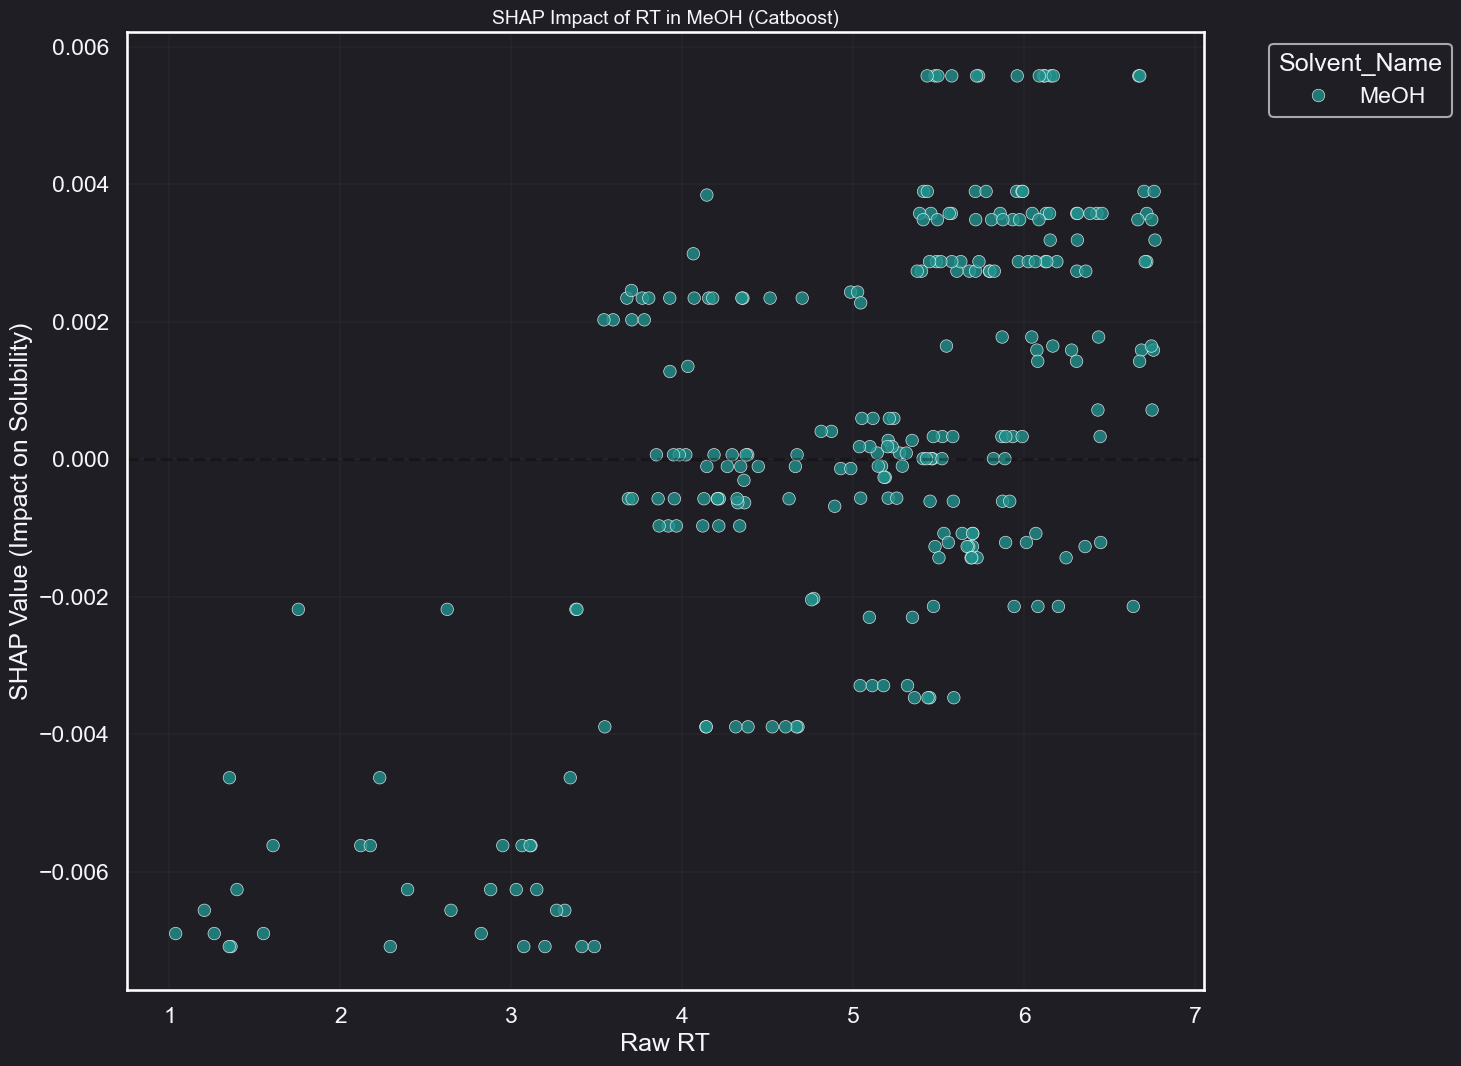

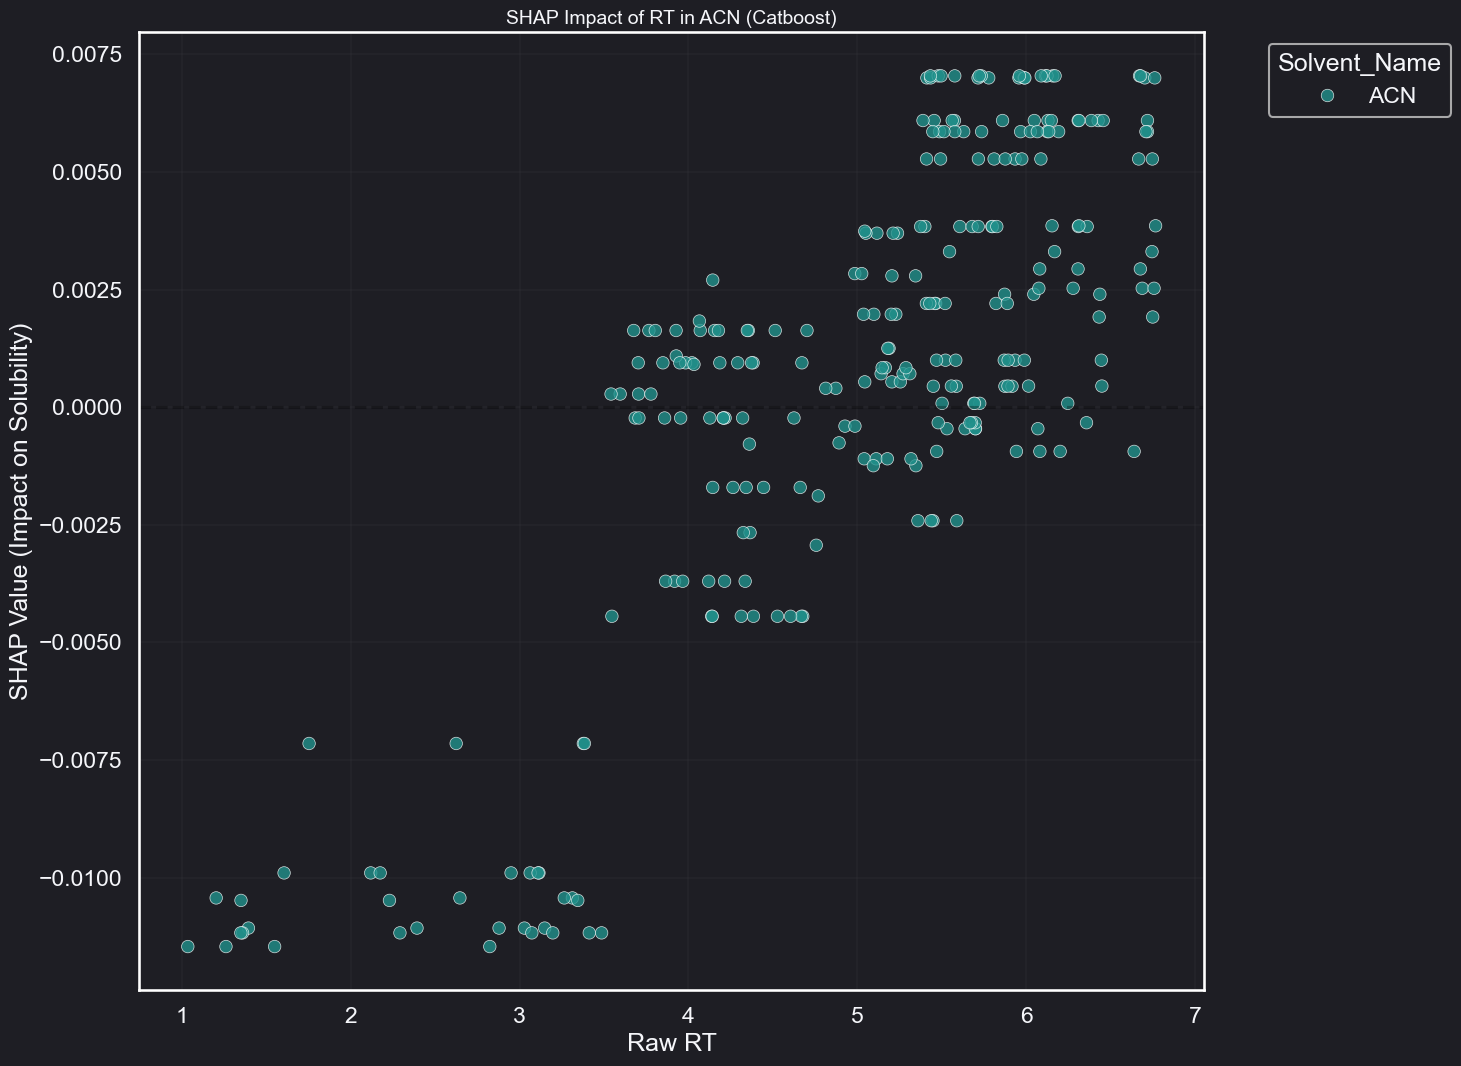

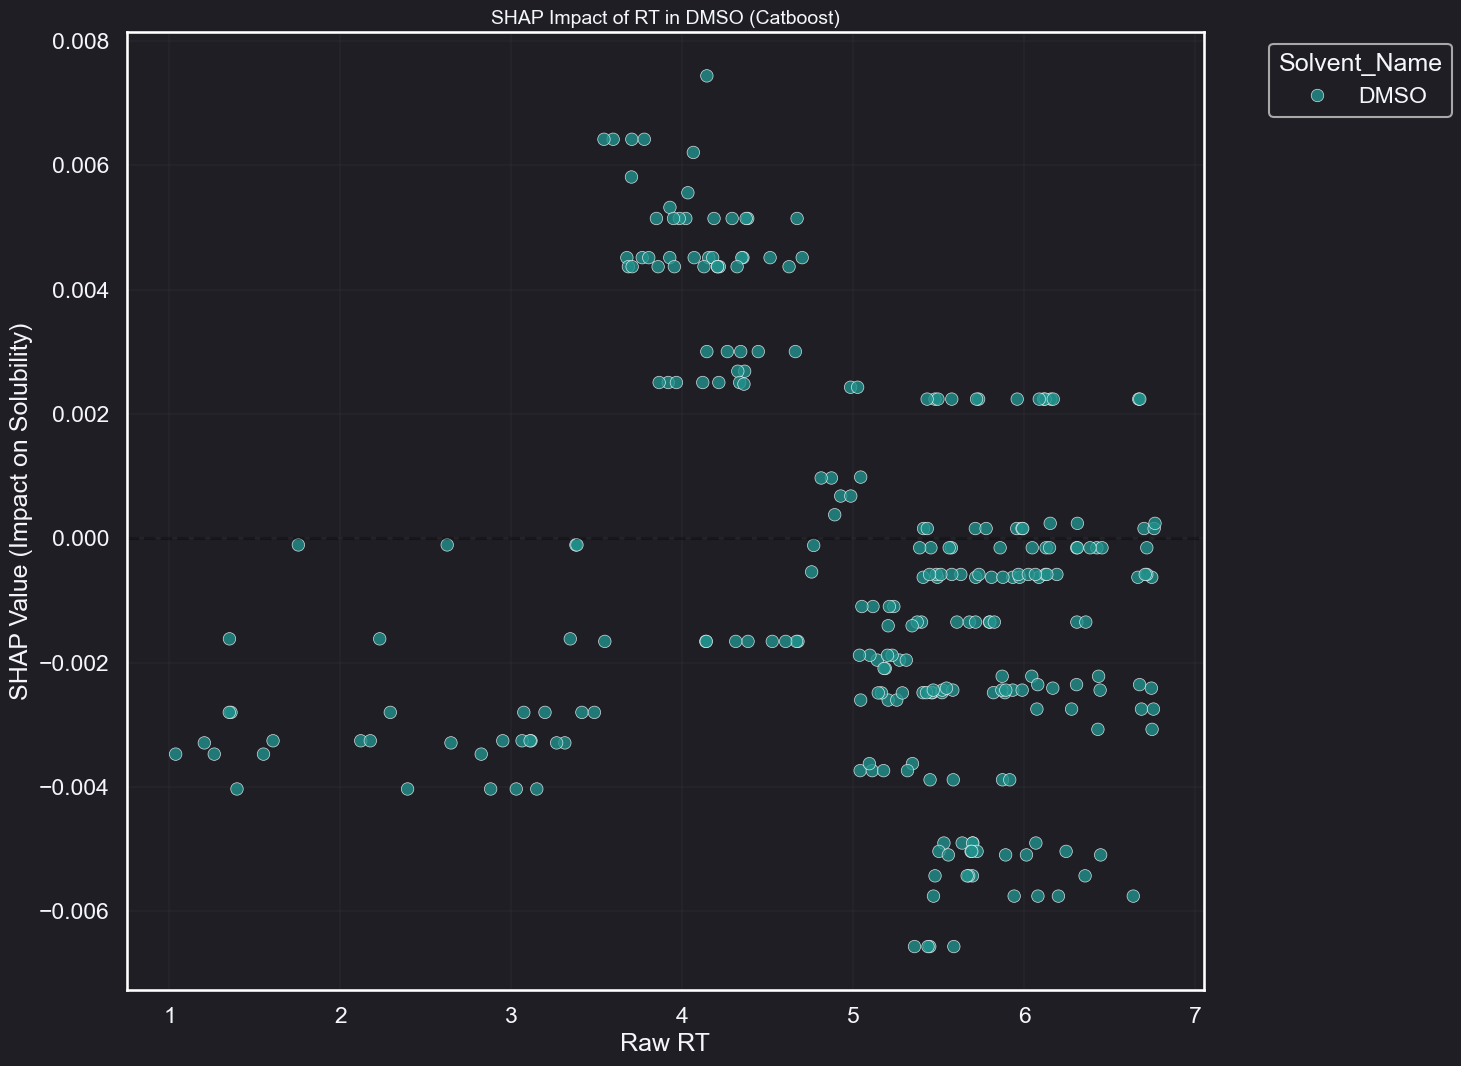

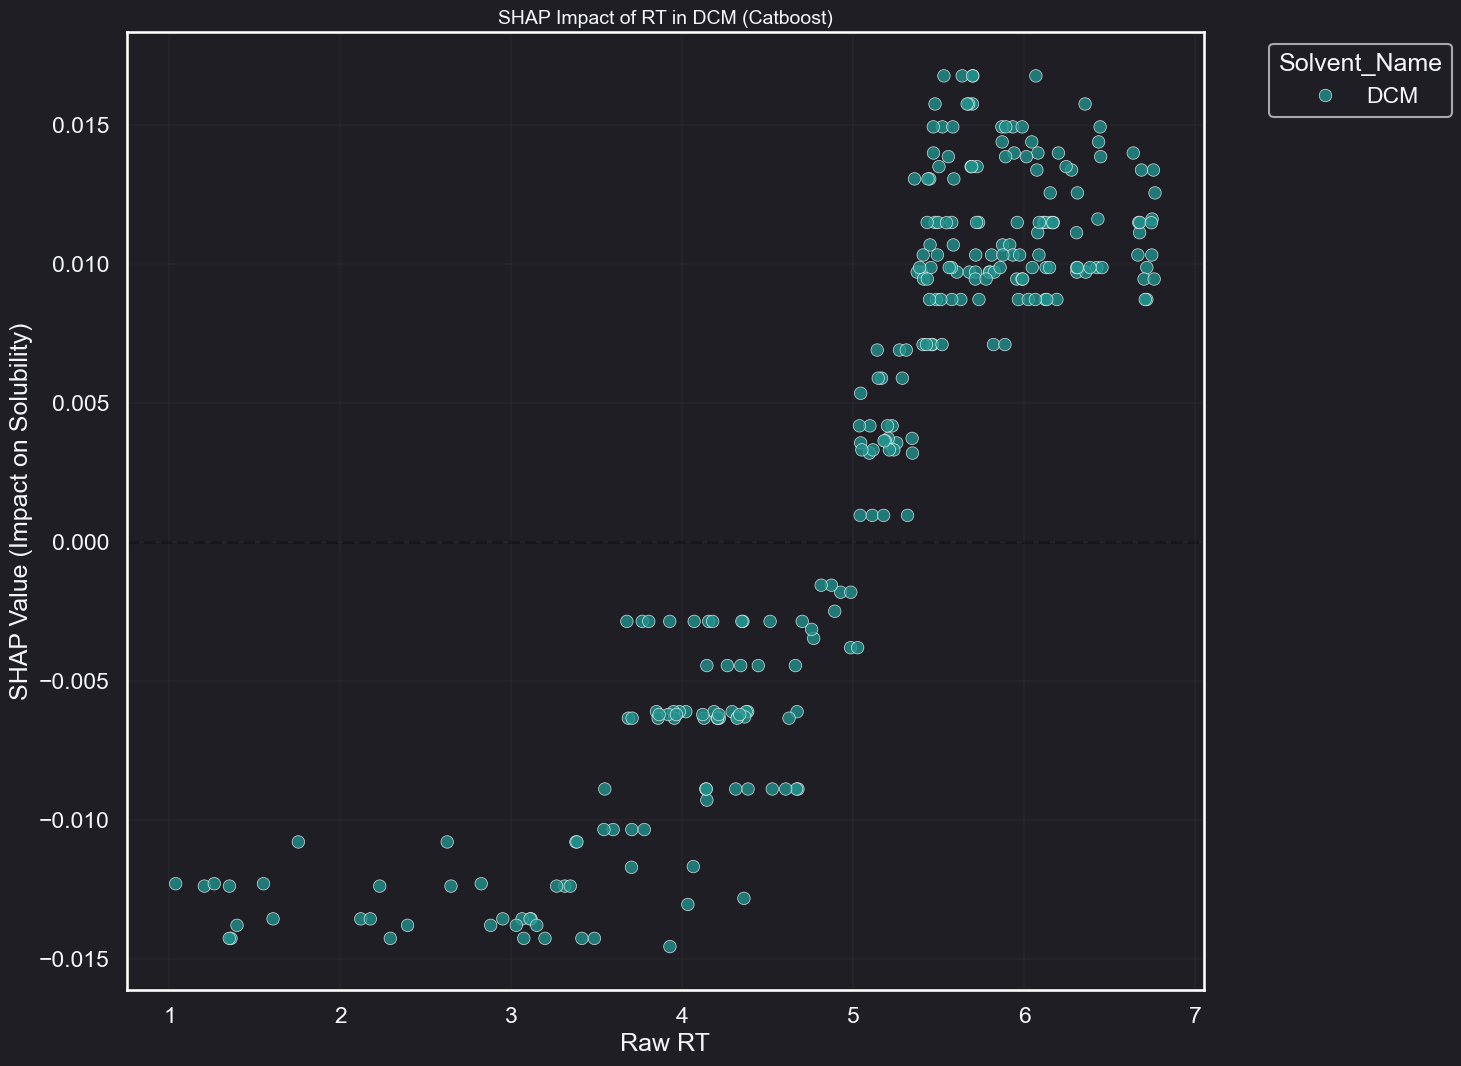

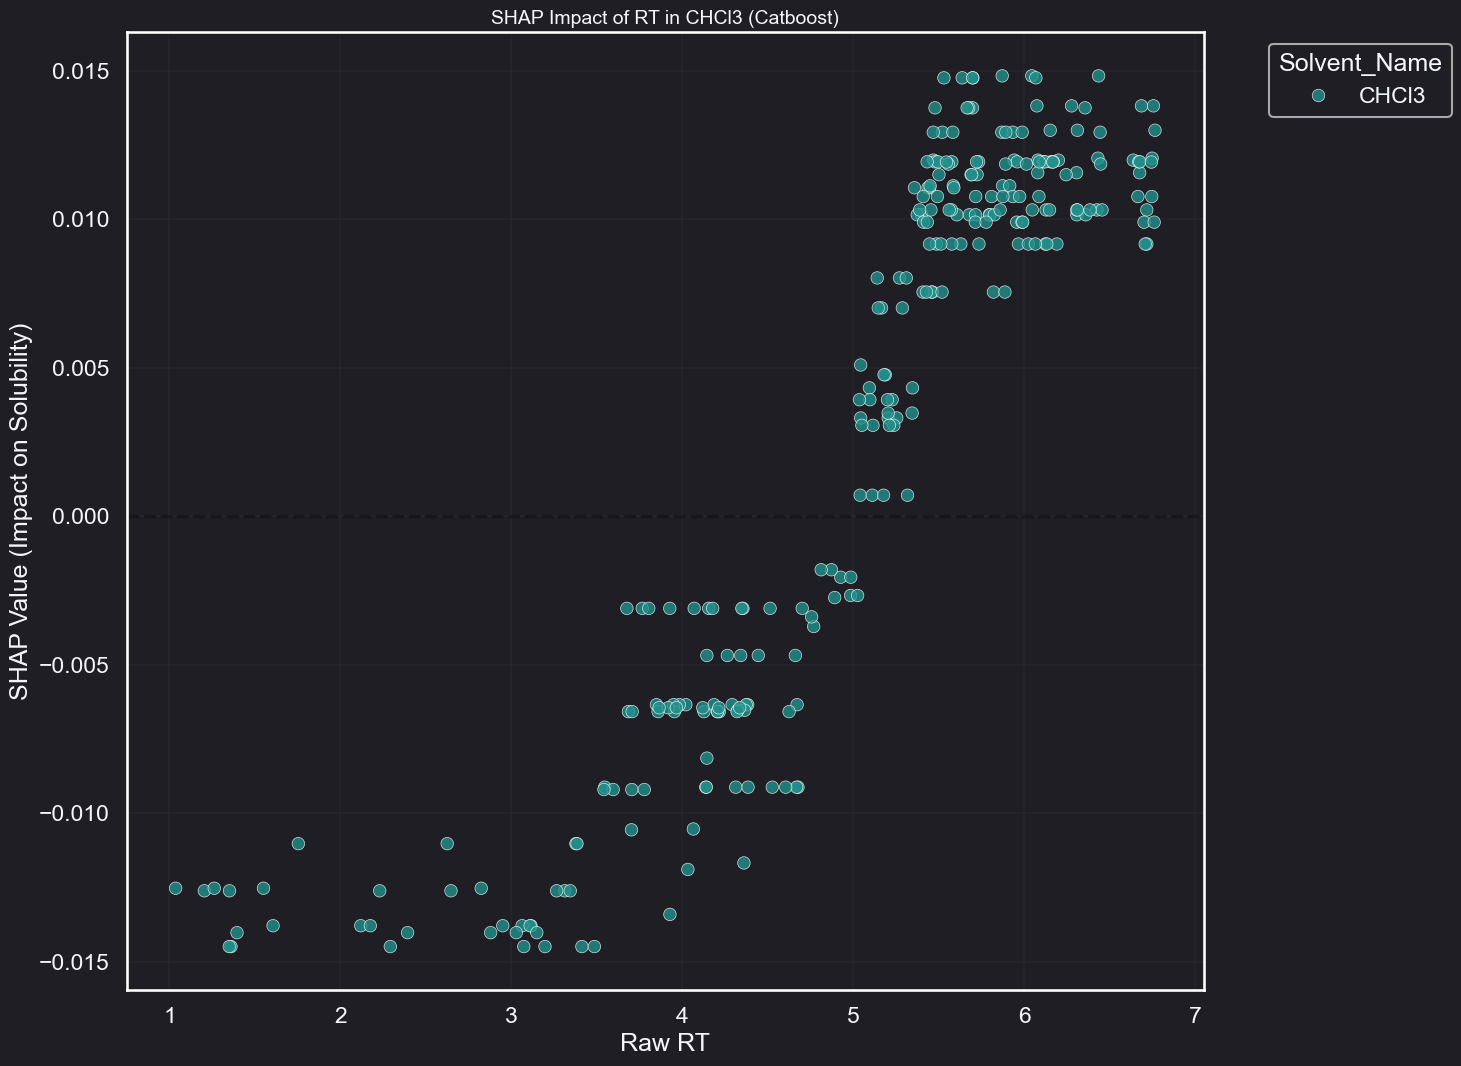

In [275]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='RT',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Solvent_Name' 
)